# Plots for my thesis report
Generate the required figures for my thesis report

1. Schematic of the whole experiement (AI generated)
2. NBack experiment results -> CWL estimation accuracy around track + global (L/M/H one each)
3. Racing gate experiment idea -> Course overview + Adaptation Steps for each segments
4. Completion Time box plot -> Adaptive and Non-Adaptive groups separated
5. Drone penalty metrics -> HeatMap of crashes + drone outside + Adaptation step within a 20s window around the crash

**Extras / Optional figures**

In [1]:
import matplotlib.pyplot as plt

In [2]:
# Data loading
from pathlib import Path
from workload_inference.plot_results._common import load_inference_data

DATA_DIR = Path("data/experiments/experiment_nback/")
data = load_inference_data(DATA_DIR)
n_sources = data["_source"].nunique()
print(f"Loaded {len(data)} rows from {n_sources} session(s).")

FileNotFoundError: No inference_data.csv files found under data\experiments\experiment_nback

C:\Users\ahebert\Desktop\user-adaptive-swarm-interfaces\services\workload_inference\src\workload_inference\plot_results\_experiment.py:720: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


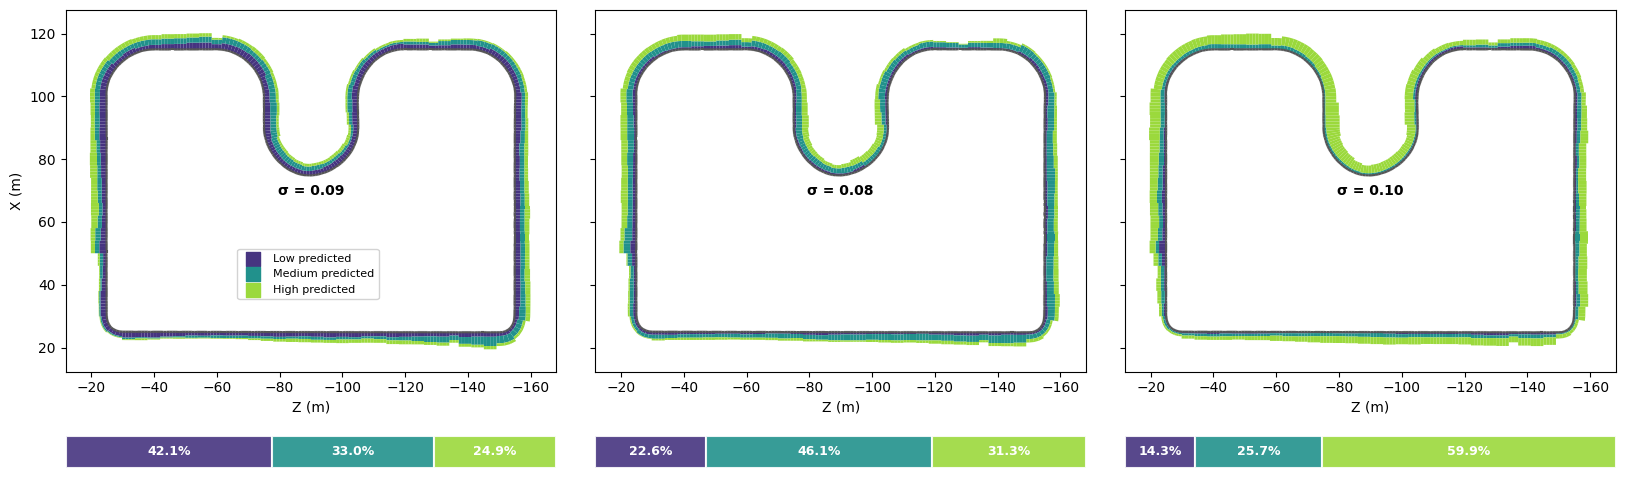

C:\Users\ahebert\Desktop\user-adaptive-swarm-interfaces\services\workload_inference\src\workload_inference\plot_results\_experiment.py:720: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


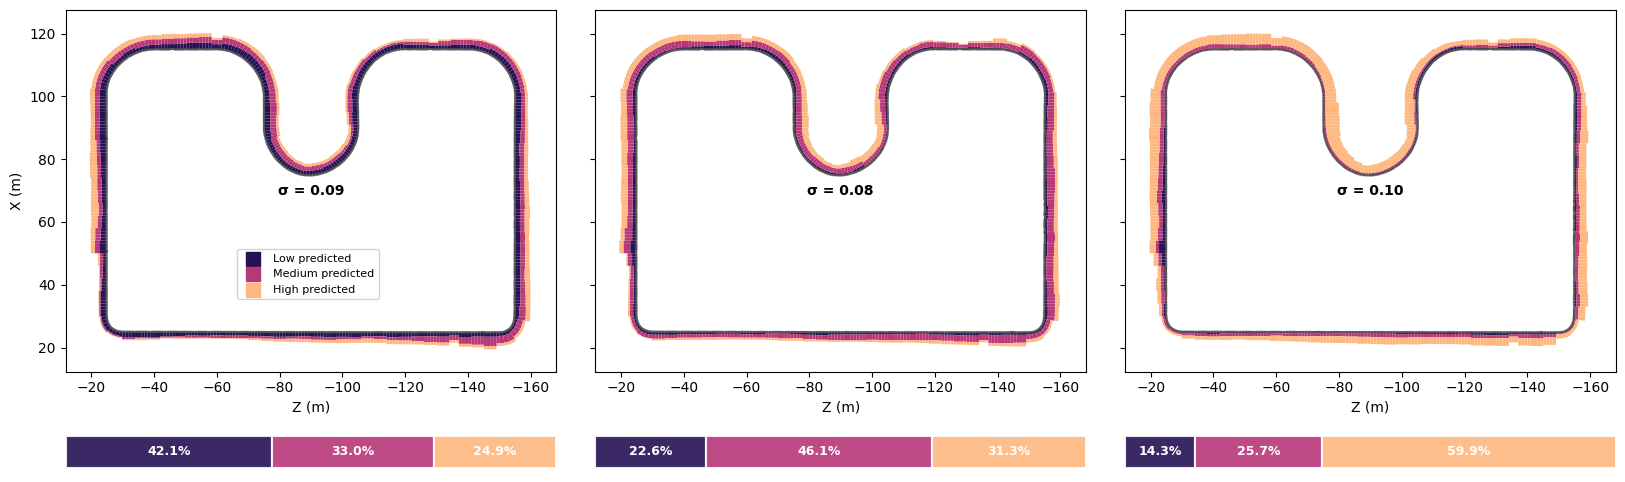

In [211]:
# 2- NBack experiment
from importlib import reload
import workload_inference.plot_results._experiment as _experiment
import workload_inference.plot_results._common as _common
reload(_experiment)
reload(_common)

from workload_inference.plot_results._experiment import (
    _collect_merged_frames,
    _plot_spline_accuracy_ribbon,
)
from workload_inference.plot_results._common import (
    _draw_spline_background,
    _load_spline,
    OKABE_ITO_CMAP,
)

merged_df = _collect_merged_frames(DATA_DIR)
spline_df = _load_spline()

# ── Layout tuning ─────────────────────────────────────────────────────────────
RIBBON_GAP  = 1.5   # height ratio of the blank separator between ribbon and summary bar
RIBBON_H    = 9     # height ratio of the ribbon row
SUMMARY_H   = 1     # height ratio of the summary bar row

# ── Colormaps ─────────────────────────────────────────────────────────────────
CMAPS = {
    # "okabe_ito": OKABE_ITO_CMAP,
    "viridis":   "viridis",
    # "plasma":    "plasma",
    "magma":     "magma",
}

for cmap_name, cmap_val in CMAPS.items():
    fig_r, axes = plt.subplots(
        3, 3,
        figsize=(20, 6),
        gridspec_kw={
            "height_ratios": [RIBBON_H, RIBBON_GAP, SUMMARY_H],
            "wspace": 0.08,
            "hspace": 0.0,
        },
    )
    # Hide the spacer row
    for ax in axes[1, :]:
        ax.set_visible(False)

    for col, cwl_plot in enumerate((0, 1, 2)):
        ax_r = axes[0, col]
        ax_summary = axes[2, col]
        _draw_spline_background(ax_r, spline_df)
        _plot_spline_accuracy_ribbon(
            ax_r, spline_df, merged_df, cwl_plot,
            ax_summary=ax_summary,
            cmap=cmap_val,
            show_legend=(col == 0),
        )
        if col > 0:
            ax_r.set_ylabel("")
            ax_r.tick_params(labelleft=False)

    out_path = f"data/results/trajectory_cwl_ribbon_all_{cmap_name}.svg"
    fig_r.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# 2c — Significance test: inferred CWL distribution across n-back conditions
# ─────────────────────────────────────────────────────────────────────────────
# Design: within-subjects (every participant did all 3 n-back levels).
# Unit of analysis: per-subject mean of filtered_state (avoids timestep
# pseudo-replication while preserving the repeated-measures structure).
#
# Primary:   Friedman test  (non-parametric repeated-measures ANOVA, 3 conditions)
# Post-hoc:  Wilcoxon signed-rank (paired, same subjects) + Holm-Bonferroni
# Secondary: Kruskal-Wallis + Mann-Whitney U on pooled raw timesteps
#            (NOTE: timesteps within a trial are not independent — inflated N)

import re
import itertools
import numpy as np
import pandas as pd
from scipy import stats
from workload_inference.plot_results._common import (
    _SUBJECT_RE, _detect_mode, _find_task_for_cwl,
    _load_trial_drone, _load_trial_inference, _join_cwl_to_drone,
)

# ── 1. Aggregate: mean filtered_state per subject per cwl_level ───────────────
_subject_dirs = sorted(
    d for d in DATA_DIR.iterdir()
    if d.is_dir() and _SUBJECT_RE.match(d.name) and not d.name.startswith("_")
)

records = []
raw_pools = {0: [], 1: [], 2: []}   # for secondary KW/MWU test

for cwl_level in (0, 1, 2):
    for subj_dir in _subject_dirs:
        task = _find_task_for_cwl(subj_dir, cwl_level)
        if task is None:
            continue
        task_dir = subj_dir / task
        trial_dirs = sorted(
            d for d in task_dir.iterdir()
            if d.is_dir() and d.name.startswith("trial_")
        )
        frames = []
        for trial_dir in trial_dirs:
            drone_df = _load_trial_drone(trial_dir)
            inf_df   = _load_trial_inference(trial_dir)
            if drone_df is None or inf_df is None:
                continue
            merged = _join_cwl_to_drone(drone_df, inf_df)
            if not merged.empty:
                frames.append(merged)
        if not frames:
            continue
        all_data = pd.concat(frames, ignore_index=True)
        vals = all_data["filtered_state"].dropna().astype(float)
        records.append({"subject": subj_dir.name, "cwl_level": cwl_level, "mean_pred": vals.mean()})
        raw_pools[cwl_level].extend(vals.tolist())

agg_df = pd.DataFrame(records)

# Pivot to subjects x conditions matrix (only subjects with all 3 levels)
pivot = agg_df.pivot(index="subject", columns="cwl_level", values="mean_pred").dropna()
print(f"Subjects with complete data (all 3 levels): {len(pivot)}")
print(pivot.round(3).to_string())

# ── 2. Friedman test (overall) ────────────────────────────────────────────────
g0, g1, g2 = pivot[0].values, pivot[1].values, pivot[2].values
friedman_stat, friedman_p = stats.friedmanchisquare(g0, g1, g2)
print(f"{'='*55}")
print(f"  Friedman test (overall, within-subjects, n={len(pivot)})")
print(f"  chi2(2) = {friedman_stat:.3f},  p = {friedman_p:.4f}")

# ── 3. Pairwise Wilcoxon signed-rank + Holm correction ───────────────────────
pairs = [(0, 1), (0, 2), (1, 2)]
pair_labels = ["0-back vs 1-back", "0-back vs 2-back", "1-back vs 2-back"]
raw_ps, stats_w = [], []
for a, b in pairs:
    w, p = stats.wilcoxon(pivot[a].values, pivot[b].values)
    raw_ps.append(p)
    stats_w.append(w)

# Holm-Bonferroni correction
order   = np.argsort(raw_ps)
adj_ps  = np.empty(len(raw_ps))
running = 0.0
for rank, idx in enumerate(order):
    corrected = raw_ps[idx] * (len(raw_ps) - rank)
    running = max(running, corrected)
    adj_ps[idx] = min(running, 1.0)

print(f"  Pairwise Wilcoxon signed-rank (Holm-Bonferroni corrected):")
print(f"  {'Pair':<22} {'W':>7}  {'p (raw)':>10}  {'p (adj)':>10}  sig")
for i, (label, w, p_raw, p_adj) in enumerate(zip(pair_labels, stats_w, raw_ps, adj_ps)):
    sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else "n.s."
    print(f"  {label:<22} {w:>7.1f}  {p_raw:>10.4f}  {p_adj:>10.4f}  {sig}")

# ── 4. Descriptive stats per condition ───────────────────────────────────────
print(f"  Descriptive (mean +/- std of per-subject means):")
for lvl, label in zip((0, 1, 2), ("0-back", "1-back", "2-back")):
    col = pivot[lvl]
    print(f"  {label}: {col.mean():.3f} +/- {col.std():.3f}  (n={len(col)})")

# ── 5. Secondary: Kruskal-Wallis + Mann-Whitney U on raw pooled timesteps ─────
print(f"{'='*55}")
print("  [Secondary] Kruskal-Wallis on raw pooled timesteps")
print("  NOTE: Timesteps within a trial are autocorrelated — N is inflated.reat as a sensitivity check, not a primary result.")
kw_stat, kw_p = stats.kruskal(raw_pools[0], raw_pools[1], raw_pools[2])
n_raw = [len(raw_pools[k]) for k in (0, 1, 2)]
print(f"  H(2) = {kw_stat:.3f},  p = {kw_p:.4f}  (n per cond: {n_raw[0]}, {n_raw[1]}, {n_raw[2]})")

print(f"  Pairwise Mann-Whitney U (Holm-Bonferroni corrected):")
mw_raw_ps, mw_stats = [], []
for a, b in pairs:
    u, p = stats.mannwhitneyu(raw_pools[a], raw_pools[b], alternative="two-sided")
    mw_raw_ps.append(p)
    mw_stats.append(u)

order_mw  = np.argsort(mw_raw_ps)
adj_mw_ps = np.empty(len(mw_raw_ps))
running = 0.0
for rank, idx in enumerate(order_mw):
    corrected = mw_raw_ps[idx] * (len(mw_raw_ps) - rank)
    running = max(running, corrected)
    adj_mw_ps[idx] = min(running, 1.0)

print(f"  {'Pair':<22} {'U':>12}  {'p (raw)':>12}  {'p (adj)':>12}  sig")
for label, u, p_raw, p_adj in zip(pair_labels, mw_stats, mw_raw_ps, adj_mw_ps):
    sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else "n.s."
    print(f"  {label:<22} {u:>12.0f}  {p_raw:>12.4f}  {p_adj:>12.4f}  {sig}")
print(f"{'='*55}")


Subjects with complete data (all 3 levels): 18
cwl_level      0      1      2
subject                       
ALH0       0.907  0.430  1.745
BEN0       0.061  0.284  0.654
BRO0       0.713  1.308  1.310
FRA0       0.147  0.805  1.388
FXXW       0.590  1.287  1.758
ISNV       1.386  1.379  1.775
JCK0       1.056  1.129  1.783
JPLT       0.638  0.588  0.962
KODR       1.926  1.931  1.468
MAR0       0.576  1.176  1.409
PJNP       0.837  1.164  1.306
ROEY       1.240  1.142  1.731
SIM0       0.827  1.182  1.477
SZVR       0.852  1.264  1.683
TQVW       0.138  1.359  1.130
XSYM       1.193  0.946  1.138
YAG0       1.214  1.378  1.939
YHUE       0.805  0.893  1.569
  Friedman test (overall, within-subjects, n=18)
  chi2(2) = 18.111,  p = 0.0001
  Pairwise Wilcoxon signed-rank (Holm-Bonferroni corrected):
  Pair                         W     p (raw)     p (adj)  sig
  0-back vs 1-back          33.0      0.0208      0.0208  *
  0-back vs 2-back           5.0      0.0001      0.0002  ***
  1-bac

C:\Users\ahebert\AppData\Local\Temp\ipykernel_2216\957222339.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = _mcm.get_cmap(cmap_name)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


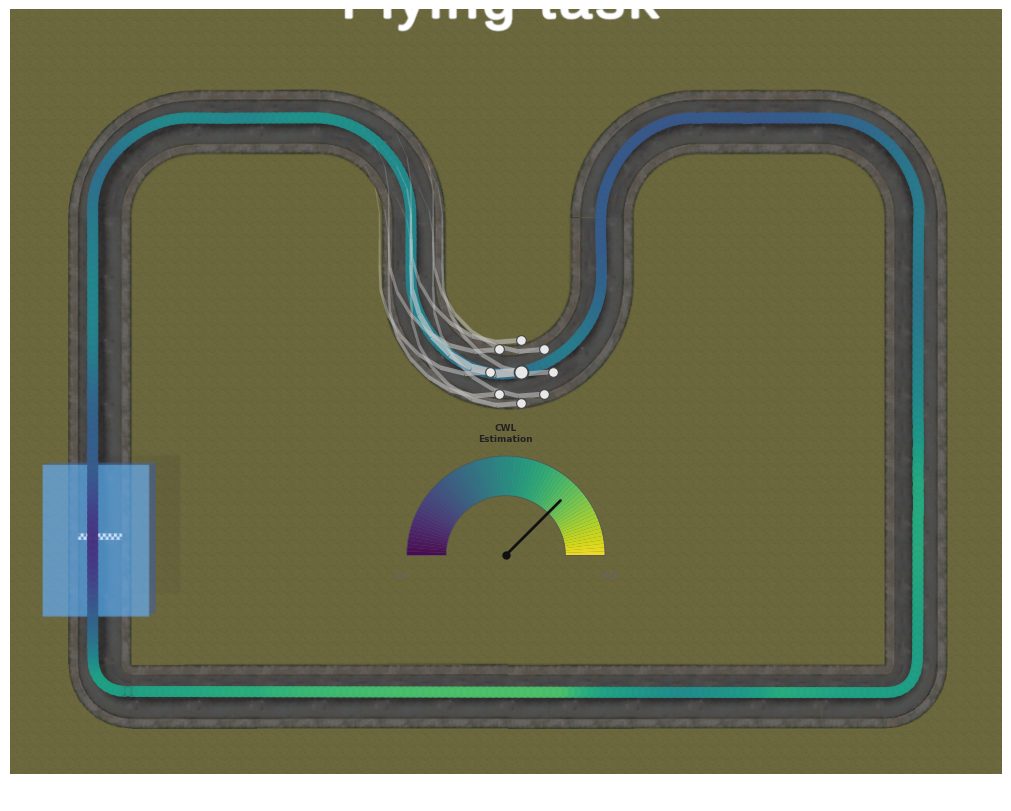

Saved -> data/results/nback_mockup_overview_viridis.pdf


C:\Users\ahebert\AppData\Local\Temp\ipykernel_2216\957222339.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = _mcm.get_cmap(cmap_name)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


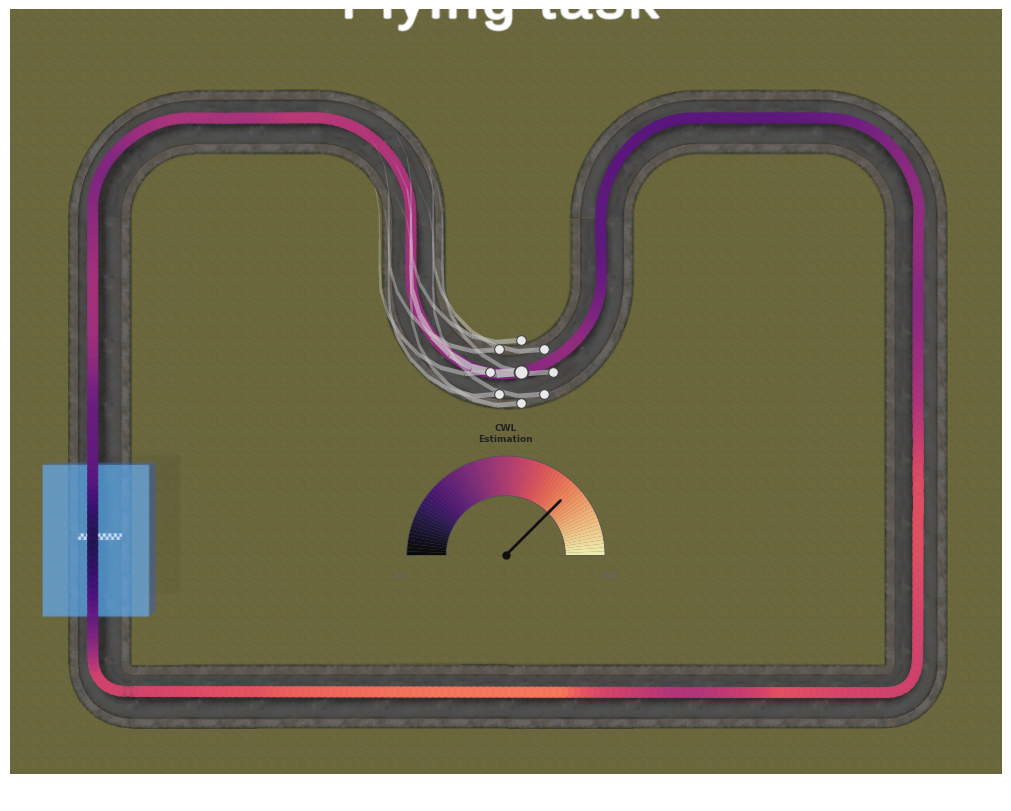

Saved -> data/results/nback_mockup_overview_magma.pdf


C:\Users\ahebert\AppData\Local\Temp\ipykernel_2216\957222339.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = _mcm.get_cmap(cmap_name)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


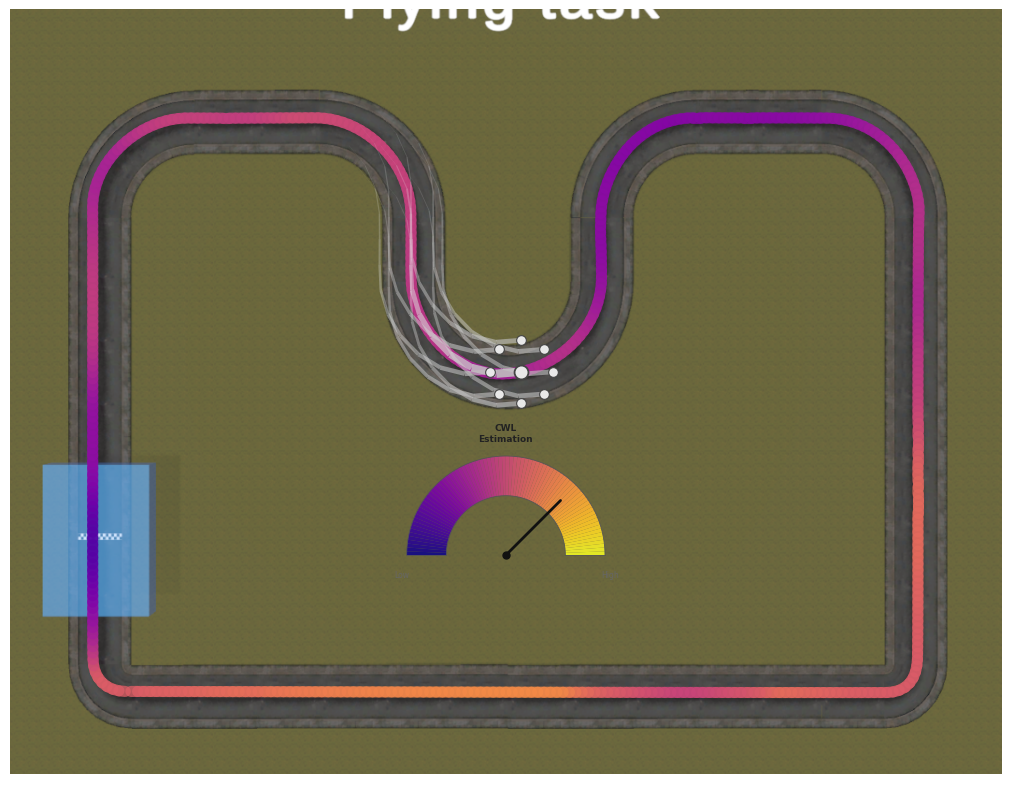

Saved -> data/results/nback_mockup_overview_plasma.pdf


In [260]:
# 2b — NBack Experiment — Mockup Overview (background image + CWL overlay + swarm + gauge)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as _mcm
import matplotlib.image as _mpimg
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
from workload_inference.plot_results._common import _load_spline, _compute_arc_param

# ── Tunable parameters ────────────────────────────────────────────────────────
_RNG_SEED    = 17
_SWARM_ARC   = 0.38
_N_TRAIL     = 12
_TRAIL_STEP  = 4
_RING_FRAC   = 0.038
_GAUGE_CWL   = 0.75
_MOCKUP_CMAPS = ["viridis", "magma", "plasma"]
_DRONE_COLOR  = "#e8e8e8"   # light grey / near-white

# Background image path
_TRACK_IMG = Path("data/nback_experiment_track.png")

# ── Image extent [z_left, z_right, x_bottom, x_top] ──────────────────────────
# Maps the image corners to world (z, x) coordinates.
# Adjust these four values if the spline doesn't align with the track.
#   z_left  : world-z at left edge of image  (spawn side, less negative)
#   z_right : world-z at right edge of image (far side, more negative)
#   x_bottom: world-x at bottom edge of image
#   x_top   : world-x at top edge of image (includes "Flying task" title)
_IMG_EXTENT = (20, -183, 12, 145)


# -- CWL: multi-scale random variation with corner suppression --
def _cwl_smooth_random(sx, sz, rng=None):
    """
    Random CWL signal with no geometric relationship to the track,
    except that sharp corners are gently prevented from showing HIGH values
    (the upper bound is softly capped proportional to local curvature).
    """
    if rng is None:
        rng = np.random.default_rng(_RNG_SEED)
    n_pts = len(sx)

    # Three noise layers at different spatial scales
    coarse = gaussian_filter1d(rng.normal(0, 1, n_pts), sigma=55, mode='wrap')
    medium = gaussian_filter1d(rng.normal(0, 1, n_pts), sigma=18, mode='wrap')
    fine   = gaussian_filter1d(rng.normal(0, 1, n_pts), sigma=5,  mode='wrap')

    # Slowly varying intensity envelope
    raw_env  = gaussian_filter1d(rng.uniform(0, 1, n_pts), sigma=70, mode='wrap')
    envelope = 0.30 + 0.70 * (raw_env - raw_env.min()) / (raw_env.max() - raw_env.min() + 1e-9)

    signal = 0.45 * coarse + (0.45 * medium + 0.10 * fine) * envelope
    signal = (signal - signal.mean()) / (signal.std() + 1e-9)
    signal = 0.50 + signal * 0.18

    # Soft upper cap at corners: curvature is normalised then used to push the
    # ceiling down so sharp turns stay in the low-to-mid range.
    dx,  dz  = np.gradient(sx), np.gradient(sz)
    ddx, ddz = np.gradient(dx), np.gradient(dz)
    k = np.abs(dx * ddz - dz * ddx) / (dx**2 + dz**2 + 1e-9)**1.5
    k = gaussian_filter1d(k, sigma=22, mode='wrap')
    k_norm    = (k - k.min()) / (k.max() - k.min() + 1e-9)
    upper_cap = 0.72 - 0.30 * k_norm   # straights: cap at 0.72; sharpest corner: cap at 0.42
    signal    = np.minimum(signal, upper_cap)

    return np.clip(signal, 0.05, 0.95).astype(np.float32)
def _draw_cwl_gauge(ax_g, cwl_val, cmap):
    n_seg = 80
    r_out, r_in = 1.0, 0.60
    for i in range(n_seg):
        frac  = (i + 0.5) / n_seg
        color = cmap(1.0 - frac)
        th = np.linspace(np.deg2rad(i / n_seg * 180),
                         np.deg2rad((i + 1) / n_seg * 180), 6)
        xs = np.concatenate([r_out * np.cos(th), r_in * np.cos(th[::-1])])
        ys = np.concatenate([r_out * np.sin(th), r_in * np.sin(th[::-1])])
        ax_g.fill(xs, ys, color=color, alpha=0.90, linewidth=0)
    th_full = np.linspace(0, np.pi, 120)
    for r in (r_out, r_in):
        ax_g.plot(r * np.cos(th_full), r * np.sin(th_full),
                  color="#555", linewidth=0.6, zorder=4)
    ax_g.plot([ r_in,  r_out], [0, 0], color="#555", linewidth=0.6, zorder=4)
    ax_g.plot([-r_out, -r_in], [0, 0], color="#555", linewidth=0.6, zorder=4)
    needle_rad = np.deg2rad((1.0 - cwl_val) * 180)
    ax_g.plot([0, 0.78 * np.cos(needle_rad)], [0, 0.78 * np.sin(needle_rad)],
              color="#111", linewidth=2.0, solid_capstyle="round", zorder=5)
    ax_g.plot(0, 0, "o", color="#111", markersize=5, zorder=6)
    ax_g.text( 0,     1.13, "CWL\nEstimation", ha="center", va="bottom",
               fontsize=6.5, fontweight="bold", color="#222", linespacing=1.2)
    ax_g.text(-1.05, -0.22, "Low",  ha="center", fontsize=5.5, color="#666")
    ax_g.text( 1.05, -0.22, "High", ha="center", fontsize=5.5, color="#666")
    ax_g.set_xlim(-1.50, 1.50)
    ax_g.set_ylim(-0.45, 1.40)
    ax_g.set_aspect("equal")
    ax_g.axis("off")


# ── Main mockup function ───────────────────────────────────────────────────────
def _plot_nback_mockup(ax_main, spline_df, cmap_name="viridis", rng_seed=_RNG_SEED):
    rng  = np.random.default_rng(rng_seed)
    cmap = _mcm.get_cmap(cmap_name)

    sx, sz = spline_df["x"].values, spline_df["z"].values
    cwl = _cwl_smooth_random(sx, sz, rng=rng)

    # ── 1. Background image ────────────────────────────────────────────────
    if _TRACK_IMG.exists():
        img = _mpimg.imread(str(_TRACK_IMG))
        ax_main.imshow(img, extent=_IMG_EXTENT, aspect='auto', zorder=0)
    else:
        ax_main.set_facecolor("#6b7c3b")   # fallback: olive background

    # ── 2. Colored trajectory — semi-transparent so image shows through ────
    pts  = np.column_stack([sz, sx])
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap, norm=Normalize(0, 1),
                          linewidth=8.0, zorder=2, capstyle="round", alpha=0.78)
    lc.set_array(cwl[:-1])
    ax_main.add_collection(lc)

    # ── 3. Axis limits (same convention as _draw_spline_background) ────────
    pad_x = (sx.max() - sx.min()) * 0.10
    pad_z = (sz.max() - sz.min()) * 0.10
    ax_main.set_ylim(sx.min() - pad_x, sx.max() + pad_x)
    ax_main.set_xlim(sz.max() + pad_z, sz.min() - pad_z)
    ax_main.set_aspect("equal", adjustable="datalim")
    ax_main.tick_params(left=False, bottom=False,
                        labelleft=False, labelbottom=False)
    for spine in ax_main.spines.values():
        spine.set_visible(False)

    # ── 4. Swarm position ──────────────────────────────────────────────────
    arc = _compute_arc_param(spline_df)
    si  = int(np.argmin(np.abs(arc - _SWARM_ARC)))
    cx, cz = sx[si], sz[si]

    track_span = max(sx.max() - sx.min(), sz.max() - sz.min())
    ring_r     = track_span * _RING_FRAC

    n_ring = 8
    angles = np.linspace(0, 2 * np.pi, n_ring, endpoint=False)
    ring_z = cz + ring_r * np.cos(angles)
    ring_x = cx + ring_r * np.sin(angles)

    # ── 5. Fading trails ───────────────────────────────────────────────────
    n_steps   = _N_TRAIL + 1
    t_indices = np.array([max(0, si - (_N_TRAIL - s) * _TRAIL_STEP)
                          for s in range(n_steps)])
    tc_z = sz[t_indices]
    tc_x = sx[t_indices]

    seg_alphas = np.linspace(0.1, 0.90, _N_TRAIL)
    seg_grays  = np.linspace(1.0, 0.75, _N_TRAIL)

    def _trail_lc(z_pts, x_pts, lw_max, alpha_scale=1.0):
        _pts  = np.column_stack([z_pts, x_pts])
        _segs = np.stack([_pts[:-1], _pts[1:]], axis=1)
        _lws  = np.linspace(0.3, lw_max, _N_TRAIL)
        _colors = [(_g, _g, _g, _a * alpha_scale)
                   for _g, _a in zip(seg_grays, seg_alphas)]
        return LineCollection(_segs, colors=_colors, linewidths=_lws,
                              zorder=3, capstyle=None)

    ax_main.add_collection(_trail_lc(tc_z, tc_x, lw_max=6.0))
    for k in range(n_ring):
        tr_z = tc_z + ring_r * np.cos(angles[k])
        tr_x = tc_x + ring_r * np.sin(angles[k])
        ax_main.add_collection(_trail_lc(tr_z, tr_x, lw_max=3.5, alpha_scale=0.7))

    # ── 6. Swarm dots — light grey / near-white ────────────────────────────
    ax_main.plot(cz, cx, "o", color=_DRONE_COLOR, markersize=10, zorder=5,
                 markeredgecolor="#444", markeredgewidth=1.3)
    ax_main.plot(ring_z, ring_x, "o", color=_DRONE_COLOR, markersize=7, zorder=5,
                 markeredgecolor="#444", markeredgewidth=0.8)

    # ── 7. CWL gauge ──────────────────────────────────────────────────────
    gauge_w = 0.30
    ax_g = ax_main.inset_axes([0.5 - gauge_w / 2, 0.22, gauge_w, gauge_w])
    _draw_cwl_gauge(ax_g, _GAUGE_CWL, cmap)


# ── Generate one figure per colormap ──────────────────────────────────────────
_spline_df = _load_spline()

for _cmap_name in _MOCKUP_CMAPS:
    _fig, _ax = plt.subplots(figsize=(10, 8))
    _plot_nback_mockup(_ax, _spline_df, cmap_name=_cmap_name)
    _fig.tight_layout(pad=0.3)
    _out = f"data/results/nback_mockup_overview_{_cmap_name}.pdf"
    _fig.savefig(_out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {_out}")


In [5]:
from workload_inference.plot_results._experiment import (
    _load_experiment_racing,
    _read_subject_adaptive_flag,
    _build_experiment_metrics
)
RACING_DATA_DIR = Path("../data/experiments/experiment_racing_gates/")
GROUP_LABELS = {
    "adaptive": "Adaptive",
    "non_adaptive": "Non-Adaptive (Control)",
    "unknown": "Unknown",
}

by_subject = _load_experiment_racing(RACING_DATA_DIR)
if not by_subject:
    print("  No subject folders with racing trials found.")

groups = {sid: _read_subject_adaptive_flag(RACING_DATA_DIR / sid) for sid in by_subject}
n_total_trials = sum(len(t) for t in by_subject.values())
print(f"  Loaded {len(by_subject)} subject(s), {n_total_trials} trial(s)")
print("\n  Group classification (from extra_info.yml):")
for sid in sorted(by_subject):
    print(f"    {sid}  ->  {GROUP_LABELS[groups[sid]]}")
df = _build_experiment_metrics(by_subject, groups)
if df.empty:
    print("  No trial metrics could be computed.")

  Loaded 20 subject(s), 100 trial(s)

  Group classification (from extra_info.yml):
    CXOE  ->  Adaptive
    EBET  ->  Adaptive
    ENBW  ->  Non-Adaptive (Control)
    ENJS  ->  Adaptive
    ENQK  ->  Adaptive
    FACR  ->  Non-Adaptive (Control)
    FDHU  ->  Non-Adaptive (Control)
    FJZM  ->  Non-Adaptive (Control)
    JPNL  ->  Adaptive
    JUEC  ->  Adaptive
    JXKI  ->  Adaptive
    MSDM  ->  Non-Adaptive (Control)
    MZSB  ->  Adaptive
    TEOA  ->  Non-Adaptive (Control)
    VHFP  ->  Adaptive
    VXKX  ->  Adaptive
    XAZI  ->  Non-Adaptive (Control)
    XJTO  ->  Non-Adaptive (Control)
    XLHZ  ->  Non-Adaptive (Control)
    YPOM  ->  Non-Adaptive (Control)


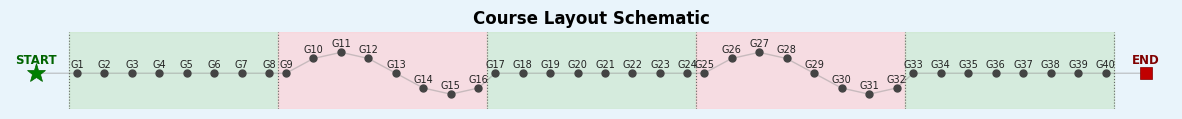

In [14]:
from workload_inference.plot_results._experiment import _build_mock_course_ax, _segment_metadata

fig, ax = plt.subplots(figsize=(15, 1))

ref_gates = next(
    (
        tr["gates"]
        for trials in by_subject.values()
        for tr in trials
        if tr["gates"] is not None
    ),
    None,
)
a_ids_ref, b_ids_ref, seg_names, seg_diffs = _segment_metadata(ref_gates)
n_segs = len(a_ids_ref)
_build_mock_course_ax(ax, seg_names, seg_diffs)
fig.patch.set_facecolor("#e9f4fb")
ax.set_facecolor("#e9f4fb")
fig.savefig("../data/results/racing_course_mockup.png", dpi=300, bbox_inches="tight")
plt.show()

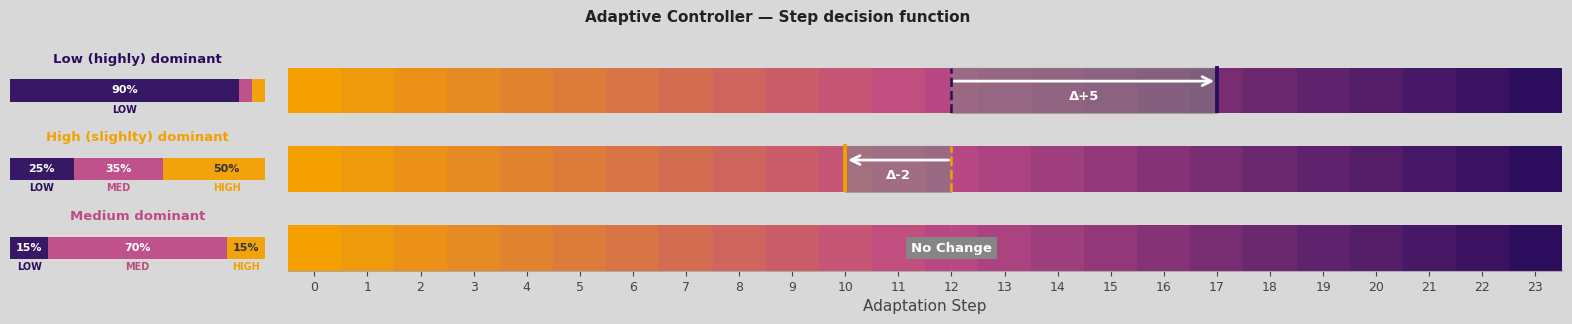

In [347]:
# 3b — Adaptive Step Controller — Decision Function
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

_BG     = "#d8d8d8"
_C_LOW  = "#f4a000"
_C_MED  = "#be4b86"
_C_HIGH = "#2d0d5e"

_COLORS      = [_C_HIGH, _C_MED, _C_LOW]
_TEXT_INSIDE = ["#ffffff", "#ffffff", "#333333"]
_LABEL_COLS  = [_C_HIGH, _C_MED, _C_LOW]

_STEP_CMAP = LinearSegmentedColormap.from_list(
    "div_cwl", [_C_LOW, _C_MED, _C_HIGH], N=256
)
_N_STEPS = 24

_SCENARIOS = [
    {"probs": [0.90, 0.05, 0.05], "from_step": 12, "to_step": 17,
     "color": _C_HIGH,    "delta": "Δ+5", "title": "Low (highly) dominant"},
    {"probs": [0.25, 0.35, 0.5], "from_step": 12, "to_step": 10,
     "color": _C_LOW,   "delta": "Δ-2", "title": "High (slighlty) dominant"},
    {"probs": [0.15, 0.70, 0.15], "from_step": 12, "to_step": 12,
     "color": _C_MED, "delta": None,  "title": "Medium dominant"},
]

_BAR_H, _BAR_BOT, _BAR_TOP, _BAR_CEN = 1.0, 0.0, 1.0, 0.5
_STEP_YLIM = (0.0, 1.5)

fig = plt.figure(figsize=(16, 3))
fig.patch.set_facecolor(_BG)
gs = GridSpec(4, 2, figure=fig, width_ratios=[1, 5],
             height_ratios=[0.18, 1, 1, 1], hspace=0.2, wspace=0.03)
fig.subplots_adjust(left=0.02, right=0.99, top=0.93, bottom=0.10)
fig.text(0.5, 0.97, "Adaptive Controller — Step decision function",
         ha="center", va="top", fontsize=11, fontweight="bold", color="#222")

ax_step_shared = None
for row, sc in enumerate(_SCENARIOS):
    c  = sc["color"]
    fs = sc["from_step"]
    ts = sc["to_step"]

    # Left: model confidence bar
    ax_prob = fig.add_subplot(gs[row + 1, 0])
    ax_prob.set_facecolor(_BG)
    cum = 0.0
    for p, cls_c, txt_c, lbl_c in zip(sc["probs"], _COLORS, _TEXT_INSIDE, _LABEL_COLS):
        ax_prob.barh([_BAR_CEN], [p], left=cum, color=cls_c,
                     height=0.5, edgecolor="none", linewidth=0.7, alpha=0.95)
        if p >= 0.15:
            ax_prob.text(cum + p / 2, _BAR_CEN, f"{p:.0%}",
                         ha="center", va="center", fontsize=8, color=txt_c, fontweight="bold")
        cum += p
    cum = 0.0
    for lbl, lbl_c, p in zip(["LOW", "MED", "HIGH"], _LABEL_COLS, sc["probs"]):
        if p >= 0.08:
            ax_prob.text(cum + p / 2, _BAR_CEN - 0.31, lbl,
                     ha="center", va="top", fontsize=7, color=lbl_c, fontweight="bold")
        cum += p
    ax_prob.text(
        0.5, _BAR_TOP + 0.05, sc["title"],
        ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", color=c,
        transform=ax_prob.transData,
    )
    ax_prob.set_xlim(0, 1)
    ax_prob.set_ylim(*_STEP_YLIM)
    ax_prob.set_xticks([])
    ax_prob.set_yticks([])
    for spine in ax_prob.spines.values():
        spine.set_visible(False)

    # Right: step gradient bar
    ax_step = fig.add_subplot(gs[row + 1, 1], sharex=ax_step_shared)
    if ax_step_shared is None:
        ax_step_shared = ax_step
    ax_step.set_facecolor(_BG)
    for s in range(_N_STEPS):
        ax_step.barh([_BAR_CEN], [1], left=s - 0.5,
                     color=_STEP_CMAP(s / (_N_STEPS - 1)), height=_BAR_H, edgecolor="none")
    ax_step.set_xlim(-0.5, _N_STEPS - 0.5)
    ax_step.set_ylim(*_STEP_YLIM)
    ax_step.set_yticks([])
    ax_step.set_xticks(range(_N_STEPS))
    ax_step.tick_params(axis="x", colors="#444", labelsize=9)
    for sp in ["top", "left", "right"]:
        ax_step.spines[sp].set_visible(False)
    if row < 2:
        ax_step.tick_params(labelbottom=False, bottom=False)
        ax_step.spines["bottom"].set_visible(False)
    else:
        ax_step.spines["bottom"].set_color("#aaa")
        ax_step.set_xticklabels([str(s) for s in range(_N_STEPS)], fontsize=9)
        ax_step.set_xlabel("Adaptation Step", fontsize=11, color="#444")
        ax_step.xaxis.label.set_color("#444")
    if fs != ts:
        x0, x1 = sorted([fs, ts])
        ax_step.fill_between([x0, x1], _BAR_BOT, _BAR_TOP,
                              color="#868686", alpha=0.55, zorder=3)
    ax_step.plot([fs, fs], [_BAR_BOT, _BAR_TOP], color=c, lw=1.8, ls="--", zorder=6)
    if ts != fs:
        ax_step.plot([ts, ts], [_BAR_BOT, _BAR_TOP], color=c, lw=2.8, zorder=7)
    if sc["delta"] is not None:
        ax_step.annotate("", xy=(ts, _BAR_CEN + 0.2), xytext=(fs, _BAR_CEN + 0.2),
                         arrowprops=dict(arrowstyle="->", color="white", lw=2.0, mutation_scale=16))
        ax_step.text((fs + ts) / 2, _BAR_CEN, sc["delta"],
                     ha="center", va="top", fontsize=9.5, color="white", fontweight="bold", zorder=9)
    else:
        ax_step.text(fs, _BAR_CEN, "No Change",
                     ha="center", va="center", fontsize=9.5, color="#FFFFFF",
                     fontweight="bold", zorder=12,
                     bbox=dict(facecolor="#868686", edgecolor="none", pad=3.5, alpha=1.0))

fig.savefig("data/results/adaptive_controller_step_decision_function.png", dpi=200, bbox_inches="tight")

plt.show()


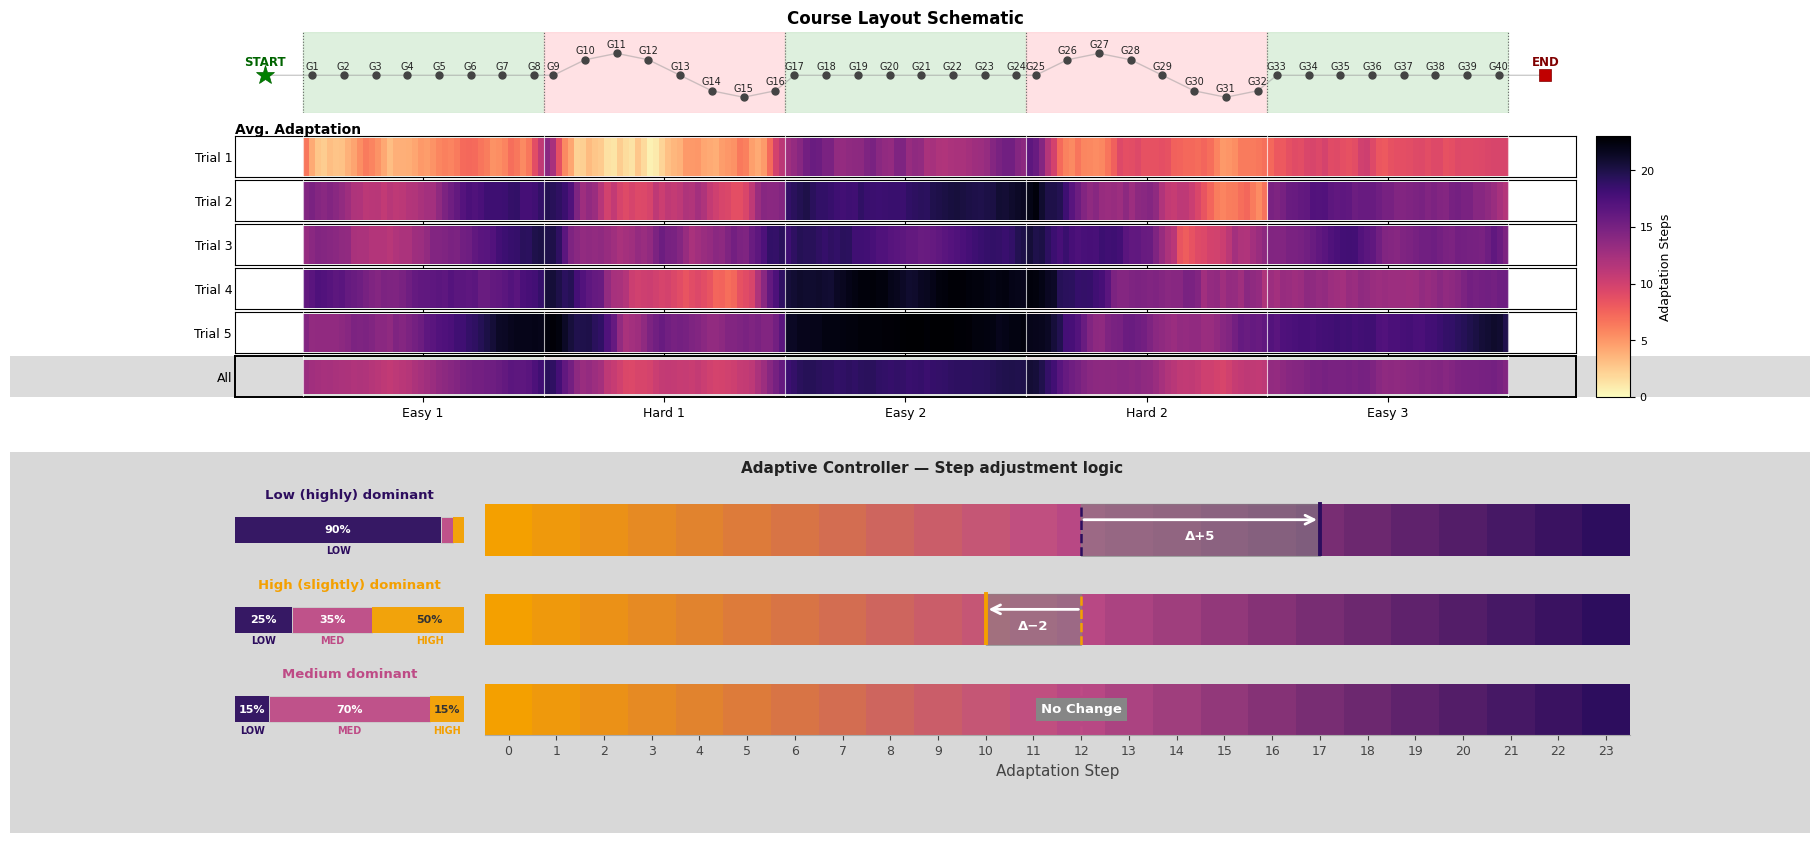

In [ ]:
# 3- Gate experiment adaptive per segment
reload(_experiment)
from workload_inference.plot_results._experiment import (
    _plot_adaptive_profile_summary,
    _build_mock_course_ax,
    _plot_step_controller_ax,
)
_PROFILE_STEP_CMAPS = ["magma_r"] #["viridis_r", "magma_r"]

n_subj = df["subject_id"].nunique()
suptitle = "Racing Gates Experiment"
n_trials_max = max(len(t) for t in by_subject.values())
n_step_rows = n_trials_max + 1  # per trial + global
n_cwl_rows = 0 #n_trials_max + 1

# Row layout: mock | spacer | step rows | spacer | cwl rows | spacer | controller
mock_h, ctrl_h, row_h, spacer_h = 1, 3.5, 0.5, 0.2
height_ratios = (
    [mock_h] + [spacer_h]
    + [row_h] * n_step_rows
    + [spacer_h] + [row_h] * n_cwl_rows
    + [0.35] + [ctrl_h]
)
# Row indices
step_row0    = 2
spacer2_row  = step_row0 + n_step_rows
cwl_row0     = spacer2_row + 1
ctrl_row     = cwl_row0 + n_cwl_rows + 1  # spacer + controller
n_rows       = ctrl_row + 1

fig_h = (mock_h + ctrl_h + spacer_h * 3
         + row_h * (n_step_rows + n_cwl_rows) + 0.80)

for cmap_name in _PROFILE_STEP_CMAPS:
    fig_p = plt.figure(figsize=(18, fig_h))
    gs_p = fig_p.add_gridspec(
        n_rows,
        2,
        height_ratios=height_ratios,
        width_ratios=[40, 1],
        hspace=0.06,
        wspace=0.03,
    )
    # Mock course: col 0 only
    ax_mock_p = fig_p.add_subplot(gs_p[0, 0])
    # Step data rows
    step_axes_p = [
        fig_p.add_subplot(gs_p[step_row0 + i, 0], sharex=ax_mock_p)
        for i in range(n_step_rows)
    ]
    # CWL data rows
    cwl_axes_p = [
        fig_p.add_subplot(gs_p[cwl_row0 + i, 0], sharex=ax_mock_p)
        for i in range(n_cwl_rows)
    ]
    # Controller at the bottom, spanning both columns
    ax_ctrl_p = fig_p.add_subplot(gs_p[ctrl_row, :])
    # Colorbar axes for step section
    cbar_step_ax = fig_p.add_subplot(gs_p[step_row0 : step_row0 + n_step_rows, 1])

    _plot_adaptive_profile_summary(
        ax_mock_p,
        step_axes_p,
        None,
        cbar_step_ax,
        None,
        by_subject,
        groups,
        step_cmap_name=cmap_name,
        cwl_cmap_name=cmap_name,
    )
    _plot_step_controller_ax(ax_ctrl_p)

    plt.subplots_adjust(top=0.9)
    fig_p.savefig(
        f"data/results/racing_gates_adaptive_profile_summary_{cmap_name}.svg",
        dpi=200,
        bbox_inches="tight",
    )

plt.show()


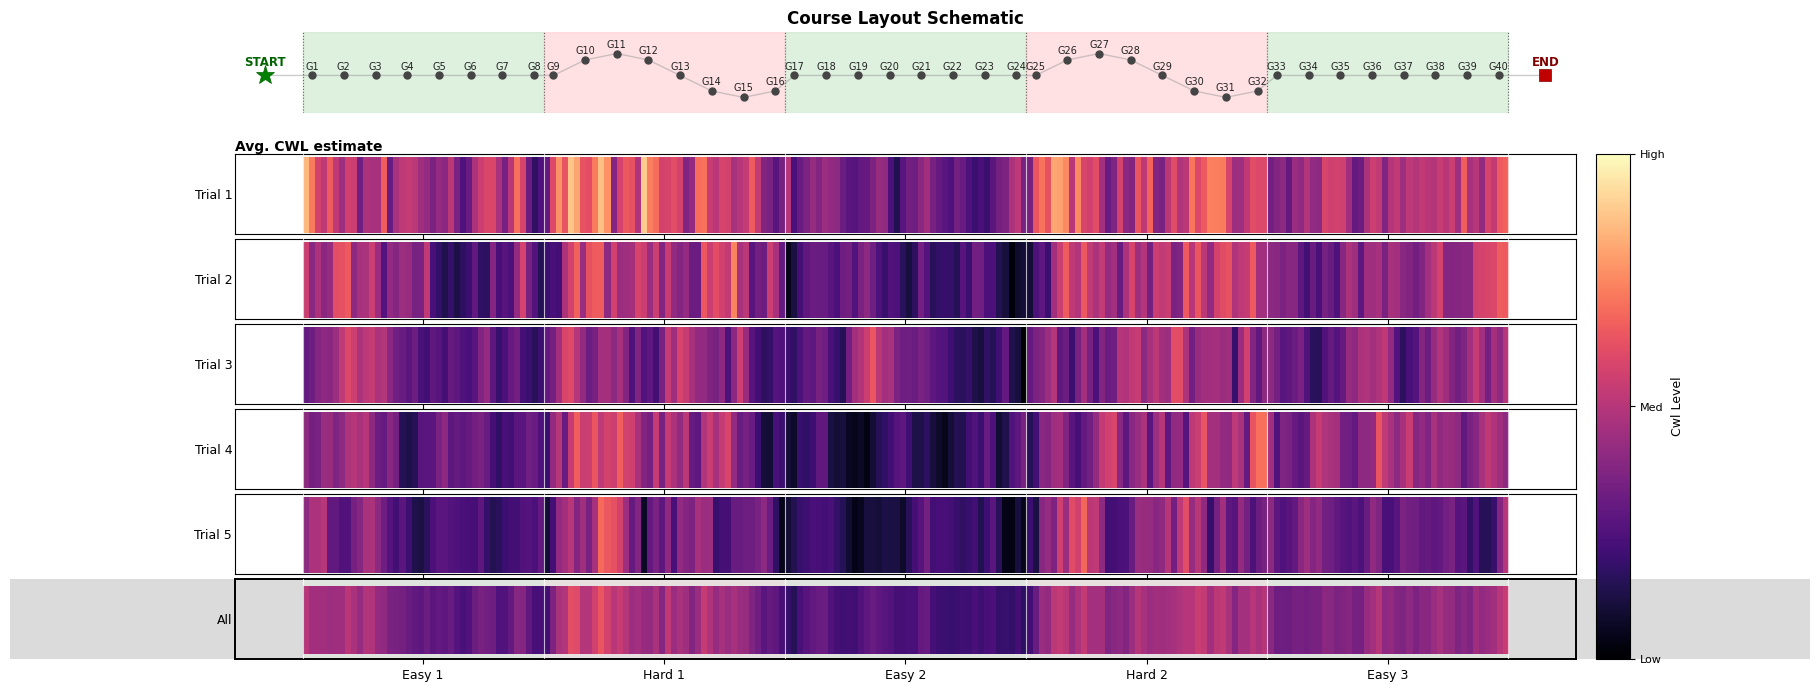

In [ ]:
# 3- Gate experiment adaptive per segment
reload(_experiment)
from workload_inference.plot_results._experiment import (
    _plot_adaptive_profile_summary,
    _build_mock_course_ax,
    _plot_step_controller_ax,
)
_PROFILE_STEP_CMAPS = ["magma_r"] #["viridis_r", "magma_r"]

n_subj = df["subject_id"].nunique()
suptitle = "Racing Gates Experiment"
n_trials_max = max(len(t) for t in by_subject.values())
n_step_rows = n_trials_max + 1  # per trial + global
n_cwl_rows = 0 #n_trials_max + 1

# Row layout: mock | spacer | step rows | spacer | cwl rows | spacer | controller
mock_h, ctrl_h, row_h, spacer_h = 0.5, 3.5, 0.5, 0.2
height_ratios = (
    [mock_h] + [spacer_h]
    + [row_h] * n_step_rows
    + [spacer_h] + [row_h] * n_cwl_rows
)
# Row indices
step_row0    = 2
spacer2_row  = step_row0 + n_step_rows
cwl_row0     = spacer2_row + 1
ctrl_row     = cwl_row0 + n_cwl_rows + 1  # spacer + controller
n_rows       = len(height_ratios)

fig_h = (mock_h + ctrl_h + spacer_h * 3
         + row_h * (n_step_rows + n_cwl_rows) + 0.80)

for cmap_name in _PROFILE_STEP_CMAPS:
    fig_p = plt.figure(figsize=(18, fig_h))
    gs_p = fig_p.add_gridspec(
        n_rows,
        2,
        height_ratios=height_ratios,
        width_ratios=[40, 1],
        hspace=0.06,
        wspace=0.03,
    )
    # Mock course: col 0 only
    ax_mock_p = fig_p.add_subplot(gs_p[0, 0])
    # Step data rows
    step_axes_p = [
        fig_p.add_subplot(gs_p[step_row0 + i, 0], sharex=ax_mock_p)
        for i in range(n_step_rows)
    ]
    # CWL data rows
    cwl_axes_p = [
        fig_p.add_subplot(gs_p[cwl_row0 + i, 0], sharex=ax_mock_p)
        for i in range(n_cwl_rows)
    ]
    # Colorbar axes for step section
    cbar_step_ax = fig_p.add_subplot(gs_p[step_row0 : step_row0 + n_step_rows, 1])

    _plot_adaptive_profile_summary(
        ax_mock_p,
        None,
        step_axes_p,
        None,
        cbar_step_ax,
        by_subject,
        groups,
        step_cmap_name="magma_r",
        cwl_cmap_name="magma",
    )

    plt.subplots_adjust(top=0.9)
    fig_p.savefig(
        f"data/results/racing_gates_adaptive_profile_cwl_{cmap_name}.svg",
        dpi=200,
        bbox_inches="tight",
    )

plt.show()

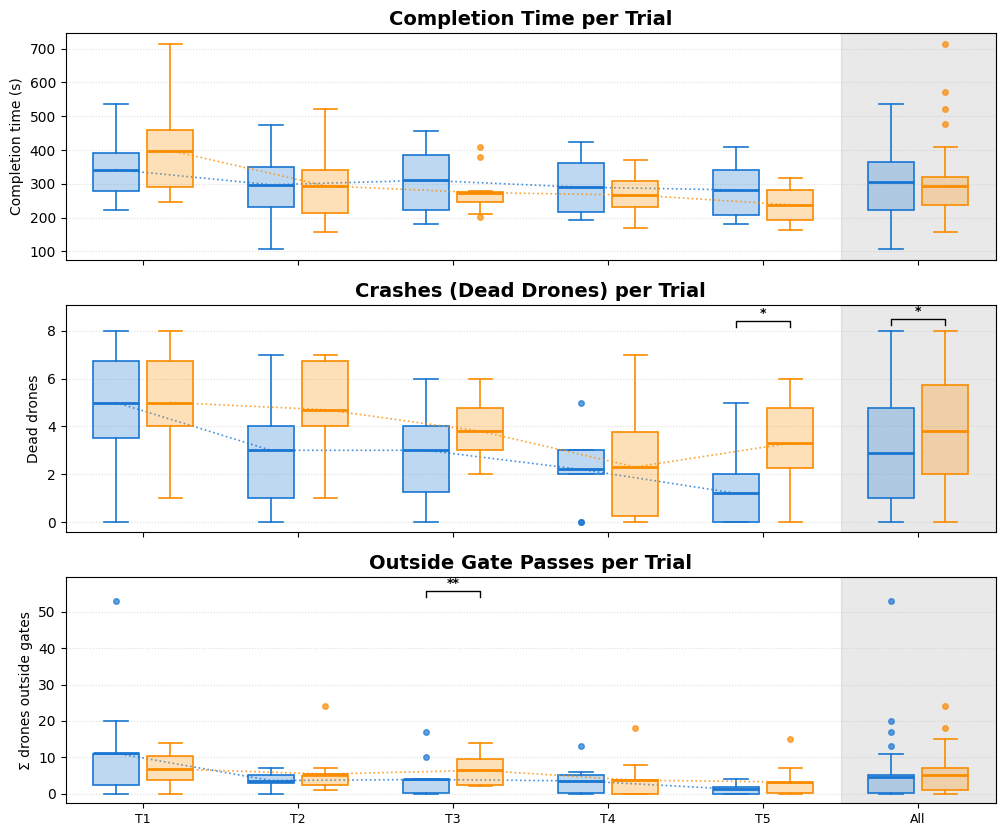

  Completion time (s)
  Trial                           Adaptive              Non-Adaptive                   p-value
--------------------------------------------------------------------------------
  trial_1          398.36 ± 141.89  (n=10)    341.92 ± 89.20  (n=10)               p=0.4727 ns
  trial_2          293.83 ± 100.01  (n=10)   297.22 ± 100.44  (n=10)               p=0.9097 ns
  trial_3           273.84 ± 64.35  (n=10)    310.21 ± 91.75  (n=10)               p=0.3638 ns
  trial_4           266.74 ± 61.97  (n=10)    290.07 ± 77.22  (n=10)               p=0.5205 ns
  trial_5           237.90 ± 50.51  (n=10)    281.91 ± 74.65  (n=10)               p=0.1620 ns
--------------------------------------------------------------------------------
  All trials       294.13 ± 105.69  (n=50)    304.27 ± 89.67  (n=50)               p=0.0684 ns

  Dead drones
  Trial                           Adaptive              Non-Adaptive                   p-value
-----------------------------------------

In [329]:
# 4- Completion Time / Crashes / Outside Passes per trial
import importlib
importlib.reload(_experiment)
from workload_inference.plot_results._experiment import (
    _plot_per_trial_group_boxplot,
    _iqr_filter,
)
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from scipy.stats import mannwhitneyu

# ── Layout tuning ─────────────────────────────────────────────────────────────
PERF_H   = 2     # height ratio of each data row
PERF_GAP = 0.4   # height ratio of spacer between rows

WITH_ADAPTATION_DYNAMIC_SIZING = False
GROUP_COLORS = {
    "adaptive":     "#FB8C00",   # orange
    "non_adaptive": "#1976D2",   # blue
    "unknown":      "#9E9E9E",
}

fig1 = plt.figure(figsize=(12, 10))
gs = GridSpec(
    5, 1, figure=fig1,
    height_ratios=[PERF_H, PERF_GAP, PERF_H, PERF_GAP, PERF_H],
    hspace=0.0,
)
ax_comp    = fig1.add_subplot(gs[0])
ax_spacer1 = fig1.add_subplot(gs[1])
ax_crashes = fig1.add_subplot(gs[2], sharex=ax_comp)
ax_spacer2 = fig1.add_subplot(gs[3])
ax_outside = fig1.add_subplot(gs[4], sharex=ax_comp)

ax_spacer1.set_visible(False)
ax_spacer2.set_visible(False)
ax_comp.tick_params(labelbottom=False)
ax_crashes.tick_params(labelbottom=False)

stars1 = _plot_per_trial_group_boxplot(
    ax_comp, df,
    "completion_s", "Completion time (s)", "Completion Time per Trial",
    better_low=True, show_legend=False,
    show_datapoints=WITH_ADAPTATION_DYNAMIC_SIZING,
)
stars2 = _plot_per_trial_group_boxplot(
    ax_crashes, df,
    "dead_drones", "Dead drones", "Crashes (Dead Drones) per Trial",
    better_low=True, show_legend=False,
)
stars3 = _plot_per_trial_group_boxplot(
    ax_outside, df,
    "missed_drones", "Σ drones outside gates", "Outside Gate Passes per Trial",
    better_low=True, show_legend=False,
)

_sc = LinearSegmentedColormap.from_list(
    "adaptive_steps", ["#C6DBEF", "#08519C"], N=256
)
if WITH_ADAPTATION_DYNAMIC_SIZING:
    _na_color = GROUP_COLORS["non_adaptive"]
    _a_color  = GROUP_COLORS["adaptive"]
    _step_legend = [
        plt.scatter([], [], s=10, color=_sc(0.0), label="Adaptive — step 0",
                    alpha=0.92, edgecolors=_a_color, linewidths=1.0),
        plt.scatter([], [], s=45, color=_sc(0.5), label="Adaptive — step ~12",
                    alpha=0.92, edgecolors=_a_color, linewidths=1.0),
        plt.scatter([], [], s=80, color=_sc(1.0), label="Adaptive — step 23",
                    alpha=0.92, edgecolors=_a_color, linewidths=1.0),
        plt.scatter([], [], s=45, color=_na_color, label="Non-Adaptive",
                    alpha=0.92, edgecolors=_na_color, linewidths=1.0),
    ]
    step_leg = ax_comp.legend(
        handles=_step_legend, title="Adapt. step",
        fontsize=8, loc="upper right", framealpha=0.9, title_fontsize=8,
    )
    ax_comp.add_artist(step_leg)
fig1.savefig("data/results/racing_gates_per_trial_boxplots_with_step_legend.svg",
                 dpi=200, bbox_inches="tight")

plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────

_METRICS = [
    ("completion_s",  "Completion time (s)"),
    ("dead_drones",   "Dead drones"),
    ("missed_drones", "Drones outside gates"),
]
_GROUPS = ["adaptive", "non_adaptive"]
_GROUP_LABELS = {"adaptive": "Adaptive", "non_adaptive": "Non-Adaptive"}
_STAR_THRESHOLDS = [(0.001, "***"), (0.01, "**"), (0.05, "*")]


def _stars(p: float) -> str:
    for thresh, label in _STAR_THRESHOLDS:
        if p < thresh:
            return label
    return "ns"


def print_metrics_summary(data: "pd.DataFrame") -> None:
    trials = sorted(data["trial"].unique())
    col_w = 26

    for metric_col, metric_label in _METRICS:
        print("=" * 80)
        print(f"  {metric_label}")
        print("=" * 80)
        header = f"  {'Trial':<14}" + "".join(
            f"{_GROUP_LABELS[g]:>{col_w}}" for g in _GROUPS
        ) + f"{'p-value':>{col_w}}"
        print(header)
        print("-" * 80)

        for trial in trials:
            row = data[data["trial"] == trial]
            parts = []
            vals_by_group = {}
            for g in _GROUPS:
                v = row.loc[row["group"] == g, metric_col].dropna().values
                vals_by_group[g] = v
                if len(v):
                    parts.append(f"{v.mean():.2f} ± {v.std():.2f}  (n={len(v)})")
                else:
                    parts.append("—")

            a_raw = vals_by_group.get("adaptive", [])
            b_raw = vals_by_group.get("non_adaptive", [])
            a = _iqr_filter(a_raw) if len(a_raw) >= 2 else a_raw
            b = _iqr_filter(b_raw) if len(b_raw) >= 2 else b_raw
            if len(a) >= 2 and len(b) >= 2:
                stat, p = mannwhitneyu(a, b, alternative="two-sided")
                p_str = f"p={p:.4f} {_stars(p)}"
            else:
                p_str = "—"

            line = f"  {trial:<14}" + "".join(f"{s:>{col_w}}" for s in parts) + f"{p_str:>{col_w}}"
            print(line)

        # Overall (all trials pooled)
        print("-" * 80)
        parts = []
        vals_by_group = {}
        for g in _GROUPS:
            v = data.loc[data["group"] == g, metric_col].dropna().values
            vals_by_group[g] = v
            if len(v):
                parts.append(f"{v.mean():.2f} ± {v.std():.2f}  (n={len(v)})")
            else:
                parts.append("—")
        a_raw = vals_by_group.get("adaptive", [])
        b_raw = vals_by_group.get("non_adaptive", [])
        a = _iqr_filter(a_raw) if len(a_raw) >= 2 else a_raw
        b = _iqr_filter(b_raw) if len(b_raw) >= 2 else b_raw
        if len(a) >= 2 and len(b) >= 2:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            p_str = f"p={p:.4f} {_stars(p)}"
        else:
            p_str = "—"
        line = f"  {'All trials':<14}" + "".join(f"{s:>{col_w}}" for s in parts) + f"{p_str:>{col_w}}"
        print(line)
        print()


print_metrics_summary(df)


In [ ]:
# 4d — Learning effect: trial 1 vs 5 significance + slope across trials
# ─────────────────────────────────────────────────────────────────────────────
# Within each group (adaptive / non-adaptive), tests whether completion time
# changed significantly from trial 1 to trial 5, and quantifies the
# learning trajectory across all 5 trials per subject.
#
# Trial 1 vs 5:
#   Wilcoxon signed-rank (paired) when both trials are available per subject.
#   Falls back to Mann-Whitney U (unpaired) if pairing is incomplete.
#
# Slope across trials (per subject, then summarised per group):
#   - Spearman rho: rank-based monotonic correlation (trial_num vs completion_s)
#   - Linear beta: OLS slope in seconds/trial (more interpretable in a report)
#   Both are tested against 0 with a one-sample Wilcoxon signed-rank test.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

TARGET_GROUPS = ["adaptive", "non_adaptive"]

# Extract integer trial number from "trial_1", "trial_2", ... strings
_df = df[df["group"].isin(TARGET_GROUPS)].copy()
_df["trial_num"] = _df["trial"].str.extract(r"(\d+)$").astype(int)

# ── 1. Trial 1 vs trial 5: paired Wilcoxon signed-rank per group ─────────────
print("Trial 1 vs Trial 5 — Wilcoxon signed-rank (paired within subject)")
print("=" * 60)
for group in TARGET_GROUPS:
    g = _df[_df["group"] == group]
    t1 = g[g["trial_num"] == 1].set_index("subject_id")["completion_s"]
    t5 = g[g["trial_num"] == 5].set_index("subject_id")["completion_s"]
    common = t1.index.intersection(t5.index)

    if len(common) < 2:
        print(f"  {GROUP_LABELS[group]}: not enough paired subjects (n={len(common)})")
        continue

    paired_1 = t1.loc[common].values
    paired_5 = t5.loc[common].values
    delta = paired_5 - paired_1   # positive = slower, negative = improved

    if np.all(delta == 0):
        print(f"  {GROUP_LABELS[group]}: all differences are zero, test not applicable")
        continue

    w_stat, p = stats.wilcoxon(paired_1, paired_5)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"  {GROUP_LABELS[group]} (n={len(common)} paired subjects)")
    print(f"    Trial 1: {paired_1.mean():.1f} +/- {paired_1.std():.1f} s")
    print(f"    Trial 5: {paired_5.mean():.1f} +/- {paired_5.std():.1f} s")
    print(f"    Delta  : {delta.mean():+.1f} s  (negative = faster)")
    print(f"    W={w_stat:.1f},  p={p:.4f}  {sig}")
    print()

# ── 2. Per-subject slope across all trials ───────────────────────────────────
print("=" * 60)
print("Learning slope across trials 1–5 (per-subject, then per-group)")
print("=" * 60)

slope_records = []
for sid, subj in _df.groupby("subject_id"):
    subj = subj.sort_values("trial_num").dropna(subset=["completion_s"])
    if len(subj) < 3:   # need at least 3 points for a meaningful slope
        continue
    x = subj["trial_num"].values.astype(float)
    y = subj["completion_s"].values

    rho, _ = stats.spearmanr(x, y)
    beta, intercept = np.polyfit(x, y, 1)   # OLS: beta in s / trial
    group = subj["group"].iloc[0]
    slope_records.append({"subject_id": sid, "group": group, "rho": rho, "beta_s_per_trial": beta})

slope_df = pd.DataFrame(slope_records)

for group in TARGET_GROUPS:
    g = slope_df[slope_df["group"] == group]
    if g.empty:
        continue
    rhos  = g["rho"].values
    betas = g["beta_s_per_trial"].values

    # Test rho != 0 (one-sample Wilcoxon on rho values)
    if len(rhos) >= 2 and not np.all(rhos == 0):
        _, p_rho = stats.wilcoxon(rhos)
    else:
        p_rho = np.nan

    # Test beta != 0
    if len(betas) >= 2 and not np.all(betas == 0):
        _, p_beta = stats.wilcoxon(betas)
    else:
        p_beta = np.nan

    sig_rho  = "***" if p_rho  < 0.001 else "**" if p_rho  < 0.01 else "*" if p_rho  < 0.05 else "n.s."
    sig_beta = "***" if p_beta < 0.001 else "**" if p_beta < 0.01 else "*" if p_beta < 0.05 else "n.s."

    print(f"  {GROUP_LABELS[group]} (n={len(g)} subjects)")
    print(f"    Spearman rho : {rhos.mean():+.3f} +/- {rhos.std():.3f}  "
          f"(p={p_rho:.4f} {sig_rho}  |  -1=improving, +1=worsening)")
    print(f"    Linear beta  : {betas.mean():+.1f} +/- {betas.std():.1f} s/trial  "
          f"(p={p_beta:.4f} {sig_beta})")
    print()

print("Individual subject slopes:")
print(slope_df.round(3).sort_values(["group", "subject_id"]).to_string(index=False))


Trial 1 vs Trial 5 — Wilcoxon signed-rank (paired within subject)
  Adaptive (n=10 paired subjects)
    Trial 1: 398.4 +/- 141.9 s
    Trial 5: 237.9 +/- 50.5 s
    Delta  : -160.5 s  (negative = faster)
    W=0.0,  p=0.0020  **

  Non-Adaptive (Control) (n=10 paired subjects)
    Trial 1: 341.9 +/- 89.2 s
    Trial 5: 281.9 +/- 74.6 s
    Delta  : -60.0 s  (negative = faster)
    W=9.0,  p=0.0645  n.s.

Learning slope across trials 1–5 (per-subject, then per-group)
  Adaptive (n=10 subjects)
    Spearman rho : -0.730 +/- 0.338  (p=0.0039 **  |  -1=improving, +1=worsening)
    Linear beta  : -34.8 +/- 24.6 s/trial  (p=0.0039 **)

  Non-Adaptive (Control) (n=10 subjects)
    Spearman rho : -0.530 +/- 0.471  (p=0.0117 *  |  -1=improving, +1=worsening)
    Linear beta  : -12.7 +/- 22.7 s/trial  (p=0.1309 n.s.)

Individual subject slopes:
subject_id        group  rho  beta_s_per_trial
      CXOE     adaptive -0.9           -18.439
      EBET     adaptive -0.9           -27.102
      ENJS  

In [255]:
# 4c — Dispersion Analysis: Fligner-Killeen (between groups) + Spearman (within group across trials)
# ─────────────────────────────────────────────────────────────────────────────
# Test 1 (Fligner-Killeen): non-parametric test of equal spread between groups
#   H0: the two groups have equal variance at that trial / overall
#   Significant result -> one group has a wider/tighter distribution
#
# Test 2 (Spearman): monotonic trend in within-trial SD across trial numbers
#   Tests whether the spread is systematically shrinking (or growing) per group
#
# IQR filtering is applied consistently with the Mann-Whitney U tests above,
# removing extreme outliers before all statistical comparisons.
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import fligner, spearmanr
import numpy as np

_METRICS = [
    ("completion_s",  "Completion time (s)"),
    ("dead_drones",   "Dead drones"),
    ("missed_drones", "Drones outside gates"),
]
_GROUPS  = ["adaptive", "non_adaptive"]
_LABELS  = {"adaptive": "Adaptive", "non_adaptive": "Non-Adaptive"}
_STAR    = [(0.001, "***"), (0.01, "**"), (0.05, "*")]


def _stars(p: float) -> str:
    for t, s in _STAR:
        if p < t:
            return s
    return "ns"


trials     = sorted(df["trial"].unique())
trial_nums = {t: i + 1 for i, t in enumerate(trials)}

for metric_col, metric_label in _METRICS:
    print("=" * 82)
    print(f"  {metric_label}")
    print("=" * 82)

    # ── 1. Fligner-Killeen per trial (and pooled) ─────────────────────────────
    print("  [1] Fligner-Killeen — spread difference between groups")
    print(f"  {'Trial':<12} {'Adaptive SD':>14} {'Non-Adapt SD':>14} {'FK stat':>10} {'p-value':>16}")
    print("  " + "-" * 70)
    all_a, all_b = [], []
    for trial in trials:
        row = df[df["trial"] == trial]
        a   = _iqr_filter(row.loc[row["group"] == "adaptive",     metric_col].dropna().values)
        b   = _iqr_filter(row.loc[row["group"] == "non_adaptive", metric_col].dropna().values)
        all_a.extend(a)
        all_b.extend(b)
        if len(a) >= 2 and len(b) >= 2:
            stat, p = fligner(a, b)
            print(f"  {trial:<12} {np.std(a, ddof=1):>13.2f}  {np.std(b, ddof=1):>13.2f}"
                  f"  {stat:>9.3f}  p={p:.4f} {_stars(p)}")
        else:
            print(f"  {trial:<12}  insufficient data")
    a_all = _iqr_filter(np.array(all_a))
    b_all = _iqr_filter(np.array(all_b))
    stat, p = fligner(a_all, b_all)
    print("  " + "-" * 70)
    print(f"  {'All trials':<12} {np.std(a_all, ddof=1):>13.2f}  {np.std(b_all, ddof=1):>13.2f}"
          f"  {stat:>9.3f}  p={p:.4f} {_stars(p)}")

    # ── 2. Spearman on within-trial SD across trials, per group ───────────────
    print()
    print("  [2] Spearman rho — trial number vs. within-trial SD (per group)")
    print(f"  {'Group':<20} {'SD trial 1–5':>36} {'rho':>8} {'p-value':>14}")
    print("  " + "-" * 82)
    for g in _GROUPS:
        sds = []
        for trial in trials:
            v = _iqr_filter(
                df.loc[(df["trial"] == trial) & (df["group"] == g), metric_col].dropna().values
            )
            sds.append(np.std(v, ddof=1) if len(v) >= 2 else np.nan)
        valid = [(trial_nums[t], s) for t, s in zip(trials, sds) if not np.isnan(s)]
        if len(valid) >= 3:
            ns_v, sds_v = zip(*valid)
            rho, p = spearmanr(ns_v, sds_v)
            sd_str = "  ".join(f"{s:.1f}" for s in sds)
            print(f"  {_LABELS[g]:<20} [{sd_str}]  {rho:>+.3f}  p={p:.4f} {_stars(p)}")
        else:
            print(f"  {_LABELS[g]:<20}  insufficient data")
    print()


  Completion time (s)
  [1] Fligner-Killeen — spread difference between groups
  Trial           Adaptive SD   Non-Adapt SD    FK stat          p-value
  ----------------------------------------------------------------------
  trial_1             149.56          94.02      0.620  p=0.4312 ns
  trial_2             105.42         105.88      0.072  p=0.7879 ns
  trial_3              21.43          96.71      7.074  p=0.0078 **
  trial_4              65.32          81.40      0.357  p=0.5503 ns
  trial_5              53.25          78.69      3.161  p=0.0754 ns
  ----------------------------------------------------------------------
  All trials           60.82          90.58      8.005  p=0.0047 **

  [2] Spearman rho — trial number vs. within-trial SD (per group)
  Group                                        SD trial 1–5      rho        p-value
  ----------------------------------------------------------------------------------
  Adaptive             [149.6  105.4  21.4  65.3  53.2]  -

In [250]:
# 4b — Adaptation step: Hard vs. Easy segment comparison + learning effect
# ─────────────────────────────────────────────────────────────────────────────
# Course: Easy1 → Hard1 → Easy2 → Hard2 → Easy3  (5 segments, 4 transitions)
# 1. Global Hard vs. Easy pooled Mann-Whitney U (summary metric)
# 2. The 4 direct transitions tested pairwise (all trials combined)
# 3. Same analyses repeated per trial
# 4. Summary DataFrame: trials × segment-transitions + Hard vs Easy
# 5. Learning effect DataFrame: consecutive trials × segments
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from importlib import reload
from scipy.stats import mannwhitneyu
import workload_inference.plot_results._common as _common
reload(_common)
from workload_inference.plot_results._common import _segment_metadata
from workload_inference.plot_results._experiment import _iqr_filter


def _build_segment_step_df(by_subject, groups, group_filter=None):
    """Mean adaptation step per subject × trial × segment (adaptive group only)."""
    if group_filter is None:
        group_filter = {"adaptive"}
    rows = []
    for sid, trials in by_subject.items():
        if groups.get(sid) not in group_filter:
            continue
        for t_idx, tr in enumerate(trials):
            gs    = tr.get("gate_status")
            gates = tr.get("gates")
            cmd   = tr.get("commands")
            if gs is None or gates is None or cmd is None:
                continue
            if "cwl_current_step" not in cmd.columns:
                continue

            gates = gates.drop_duplicates(subset=["id"], keep="first")
            a_ids, b_ids, seg_names, seg_diffs = _segment_metadata(gates)
            gs_idx = gs.drop_duplicates(subset=["id"]).set_index("id")

            for seg_idx, (ga, gb) in enumerate(zip(a_ids, b_ids, strict=False)):
                try:
                    t0 = float(gs_idx.loc[ga, "first_pass_timestamp"])
                    t1 = float(gs_idx.loc[gb, "first_pass_timestamp"])
                except (KeyError, TypeError):
                    continue
                if t0 <= 0 or t1 <= t0:
                    continue

                mask = (cmd["timestamp"] >= t0) & (cmd["timestamp"] <= t1)
                vals = cmd.loc[mask, "cwl_current_step"].dropna().values
                if len(vals) == 0:
                    continue

                rows.append({
                    "subject_id":  sid,
                    "trial_idx":   t_idx,
                    "trial":       tr["name"],
                    "segment_idx": seg_idx,
                    "segment":     seg_names[seg_idx] if seg_idx < len(seg_names) else f"Seg{seg_idx}",
                    "is_hard":     bool(seg_diffs[seg_idx]) if seg_idx < len(seg_diffs) else False,
                    "mean_step":   float(np.mean(vals)),
                })
    return pd.DataFrame(rows)


def _sig(p):
    for t, s in [(0.001, "***"), (0.01, "**"), (0.05, "*")]:
        if p < t:
            return s
    return "ns"


def _mwu_row(a, b):
    if len(a) < 2 or len(b) < 2:
        return None
    a_f = _iqr_filter(a)
    b_f = _iqr_filter(b)
    if len(a_f) < 2 or len(b_f) < 2:
        return None
    U, p = mannwhitneyu(a_f, b_f, alternative="two-sided")
    r_rb = 1 - 2 * U / (len(a_f) * len(b_f))
    return U, p, r_rb


def _fmt(a, b):
    """Format MWU result as 'stars (p=X.XXXX)  meanA→meanB  r=±X.XX'."""
    res = _mwu_row(a, b)
    if res is None:
        return "—"
    _, p, r_rb = res
    return f"{_sig(p)} (p={p:.4f})  {a.mean():.1f}→{b.mean():.1f}  r={r_rb:+.2f}"


def _fmt_short(a, b):
    """Compact format for narrow cells: 'stars (p=X.XXXX)'."""
    res = _mwu_row(a, b)
    if res is None:
        return "—"
    _, p, _ = res
    return f"{_sig(p)} (p={p:.4f})"


def _print_hard_easy_block(df):
    hard = df[df["is_hard"]]["mean_step"].dropna().values
    easy = df[~df["is_hard"]]["mean_step"].dropna().values
    res  = _mwu_row(hard, easy)
    if res:
        U, p, r_rb = res
        print(f"  Hard:  {hard.mean():.2f} ± {hard.std():.2f}  (n={len(hard)})")
        print(f"  Easy:  {easy.mean():.2f} ± {easy.std():.2f}  (n={len(easy)})")
        print(f"  U={U:.0f},  p={p:.4f} {_sig(p)},  r={r_rb:+.3f}")
    else:
        print("  Insufficient data.")


def _print_transitions_block(df):
    seg_idxs = sorted(df["segment_idx"].unique())
    print(f"  {'Transition':<26}  {'Left mean±std':>16}  {'Right mean±std':>16}  "
          f"{'p-value':>12}  {'r':>6}")
    print("  " + "-" * 82)
    for i in range(len(seg_idxs) - 1):
        si, sj   = seg_idxs[i], seg_idxs[i + 1]
        left_df  = df[df["segment_idx"] == si]
        right_df = df[df["segment_idx"] == sj]
        name_i = left_df["segment"].iloc[0]  if len(left_df)  else f"Seg{si}"
        name_j = right_df["segment"].iloc[0] if len(right_df) else f"Seg{sj}"
        a = left_df["mean_step"].dropna().values
        b = right_df["mean_step"].dropna().values
        res = _mwu_row(a, b)
        if res is None:
            print(f"  {name_i} → {name_j:<18}  insufficient data")
            continue
        U, p, r_rb = res
        label = f"{name_i} → {name_j}"
        print(f"  {label:<26}  {a.mean():>7.2f}±{a.std():<6.2f}  "
              f"{b.mean():>7.2f}±{b.std():<6.2f}  "
              f"{p:>10.4f} {_sig(p)}  {r_rb:>+.2f}")


def print_adaptation_mwu(seg_df):
    print("=" * 72)
    print("  1. Hard vs. Easy — all segments pooled, all trials combined")
    print("=" * 72)
    _print_hard_easy_block(seg_df)

    print()
    print("=" * 72)
    print("  2. The 4 direct transitions — all trials combined")
    print("     Easy 1 → Hard 1 → Easy 2 → Hard 2 → Easy 3")
    print("=" * 72)
    _print_transitions_block(seg_df)

    print()
    print("=" * 72)
    print("  3. Per-trial breakdown")
    print("=" * 72)
    for trial in sorted(seg_df["trial"].unique()):
        t_df = seg_df[seg_df["trial"] == trial]
        n_subj = t_df["subject_id"].nunique()
        print()
        print(f"  ── {trial}  (n={n_subj} subjects) " + "─" * 40)
        print(f"  Hard vs. Easy:")
        _print_hard_easy_block(t_df)
        print(f"  Transitions:")
        _print_transitions_block(t_df)
    print()


def make_transition_summary_df(seg_df):
    """trials × segment-transitions  —  cell = 'stars (p=X.XXXX)'."""
    seg_idxs = sorted(seg_df["segment_idx"].unique())
    transitions = []
    for i in range(len(seg_idxs) - 1):
        si, sj = seg_idxs[i], seg_idxs[i + 1]
        li = seg_df[seg_df["segment_idx"] == si]["segment"].iloc[0]
        lj = seg_df[seg_df["segment_idx"] == sj]["segment"].iloc[0]
        transitions.append((f"{li} → {lj}", si, sj))

    rows = {}
    for trial in sorted(seg_df["trial"].unique()):
        t_df = seg_df[seg_df["trial"] == trial]
        row = {
            col: _fmt_short(
                t_df[t_df["segment_idx"] == si]["mean_step"].dropna().values,
                t_df[t_df["segment_idx"] == sj]["mean_step"].dropna().values,
            )
            for col, si, sj in transitions
        }
        hard = t_df[t_df["is_hard"]]["mean_step"].dropna().values
        easy = t_df[~t_df["is_hard"]]["mean_step"].dropna().values
        row["Hard vs. Easy (all)"] = _fmt_short(hard, easy)
        rows[trial] = row

    hard_all = seg_df[seg_df["is_hard"]]["mean_step"].dropna().values
    easy_all  = seg_df[~seg_df["is_hard"]]["mean_step"].dropna().values
    rows["All"] = {
        col: _fmt_short(
            seg_df[seg_df["segment_idx"] == si]["mean_step"].dropna().values,
            seg_df[seg_df["segment_idx"] == sj]["mean_step"].dropna().values,
        )
        for col, si, sj in transitions
    }
    rows["All"]["Hard vs. Easy (all)"] = _fmt_short(hard_all, easy_all)

    cols = [col for col, _, _ in transitions] + ["Hard vs. Easy (all)"]
    return pd.DataFrame(rows, index=cols).T


def make_learning_effect_df(seg_df):
    """Consecutive-trial MWU per segment — shows the learning/adaptation effect.

    Rows  : trial_N → trial_N+1
    Cols  : each segment  (Easy 1, Hard 1, Easy 2, Hard 2, Easy 3)
    Cells : 'stars (p=X.XXXX)  meanA→meanB  r=±X.XX'

    A significant increase in mean step across trials for a given segment
    indicates that subjects are learning to sustain a higher adaptation level.
    """
    trials   = sorted(seg_df["trial"].unique())
    segments = (
        seg_df[["segment_idx", "segment"]]
        .drop_duplicates()
        .sort_values("segment_idx")
    )

    rows = {}
    for i in range(len(trials) - 1):
        ta, tb = trials[i], trials[i + 1]
        label = f"{ta} → {tb}"
        rows[label] = {
            row["segment"]: _fmt(
                seg_df[(seg_df["trial"] == ta) & (seg_df["segment_idx"] == row["segment_idx"])]["mean_step"].dropna().values,
                seg_df[(seg_df["trial"] == tb) & (seg_df["segment_idx"] == row["segment_idx"])]["mean_step"].dropna().values,
            )
            for _, row in segments.iterrows()
        }

    cols = list(segments["segment"])
    return pd.DataFrame(rows, index=cols).T


seg_df = _build_segment_step_df(by_subject, groups)
print(f"Segments in analysis: {sorted(seg_df['segment'].unique())}\n")
print_adaptation_mwu(seg_df)

print("\n── Table 1: Segment transitions within trial (Hard vs Easy) ──")
display(make_transition_summary_df(seg_df))

print("\n── Table 2: Learning effect — consecutive trial pairs per segment ──")
print("   Cell: stars (p-value)  mean_trial_N → mean_trial_N+1  effect size r")
display(make_learning_effect_df(seg_df))


Segments in analysis: ['Easy 1', 'Easy 2', 'Easy 3', 'Hard 1', 'Hard 2']

  1. Hard vs. Easy — all segments pooled, all trials combined
  Hard:  12.42 ± 6.66  (n=100)
  Easy:  15.72 ± 7.11  (n=149)
  U=5204,  p=0.0001 ***,  r=+0.301

  2. The 4 direct transitions — all trials combined
     Easy 1 → Hard 1 → Easy 2 → Hard 2 → Easy 3
  Transition                     Left mean±std    Right mean±std       p-value       r
  ----------------------------------------------------------------------------------
  Easy 1 → Hard 1               13.69±6.53      11.56±6.47        0.1001 ns  -0.19
  Hard 1 → Easy 2               11.56±6.47      19.64±4.82        0.0000 ***  +0.81
  Easy 2 → Hard 2               19.64±4.82      13.27±6.74        0.0000 ***  -0.71
  Hard 2 → Easy 3               13.27±6.74      13.77±7.92        0.5779 ns  +0.07

  3. Per-trial breakdown

  ── trial_1  (n=10 subjects) ────────────────────────────────────────
  Hard vs. Easy:
  Hard:  5.98 ± 5.86  (n=20)
  Easy:  9.35 ± 

,Easy 1 → Hard 1,Hard 1 → Easy 2,Easy 2 → Hard 2,Hard 2 → Easy 3,Hard vs. Easy (all)
trial_1,ns (p=0.3704),*** (p=0.0003),*** (p=0.0003),ns (p=0.6730),** (p=0.0072)
trial_2,ns (p=0.3075),** (p=0.0091),** (p=0.0091),ns (p=0.3447),* (p=0.0161)
trial_3,ns (p=0.2730),*** (p=0.0009),** (p=0.0100),ns (p=0.7337),ns (p=0.0613)
trial_4,ns (p=0.3075),*** (p=0.0003),*** (p=0.0007),ns (p=0.7337),** (p=0.0068)
trial_5,ns (p=0.6232),** (p=0.0019),*** (p=0.0007),ns (p=0.4727),* (p=0.0105)
All,ns (p=0.1001),*** (p=0.0000),*** (p=0.0000),ns (p=0.5779),*** (p=0.0001)



── Table 2: Learning effect — consecutive trial pairs per segment ──
   Cell: stars (p-value)  mean_trial_N → mean_trial_N+1  effect size r


,Easy 1,Hard 1,Easy 2,Hard 2,Easy 3
trial_1 → trial_2,*** (p=0.0000) 5.3→14.6 r=+1.00,** (p=0.0029) 4.3→12.0 r=+0.82,ns (p=0.0756) 13.7→19.4 r=+0.48,** (p=0.0014) 7.7→12.4 r=+0.85,ns (p=0.1530) 9.0→15.0 r=+0.40
trial_2 → trial_3,ns (p=0.8501) 14.6→15.4 r=+0.06,ns (p=0.9097) 12.0→12.4 r=-0.04,ns (p=0.1741) 19.4→21.1 r=+0.38,ns (p=0.2730) 12.4→15.3 r=+0.30,ns (p=0.9698) 15.0→14.5 r=+0.02
trial_3 → trial_4,ns (p=0.6232) 15.4→16.3 r=+0.14,ns (p=0.6232) 12.4→13.5 r=+0.14,ns (p=0.9289) 21.1→21.5 r=+0.04,ns (p=1.0000) 15.3→15.5 r=+0.00,ns (p=0.9097) 14.5→13.4 r=-0.04
trial_4 → trial_5,ns (p=0.8501) 16.3→16.8 r=+0.06,ns (p=0.3447) 13.5→15.7 r=+0.26,ns (p=0.3293) 21.5→22.5 r=+0.27,ns (p=0.9698) 15.5→15.4 r=-0.02,ns (p=0.3447) 13.4→16.4 r=+0.26


C:\Users\ahebert\Desktop\user-adaptive-swarm-interfaces\services\workload_inference\src\workload_inference\plot_results\_experiment.py:2997: RuntimeWarning: Mean of empty slice
  np.nanmean(np.array(step_by_sid[sid]), axis=0)
C:\Users\ahebert\Desktop\user-adaptive-swarm-interfaces\services\workload_inference\src\workload_inference\plot_results\_experiment.py:3000: RuntimeWarning: Mean of empty slice
  cwl_rows.append(
C:\Users\ahebert\Desktop\user-adaptive-swarm-interfaces\services\workload_inference\src\workload_inference\plot_results\_experiment.py:3004: RuntimeWarning: Mean of empty slice
  )


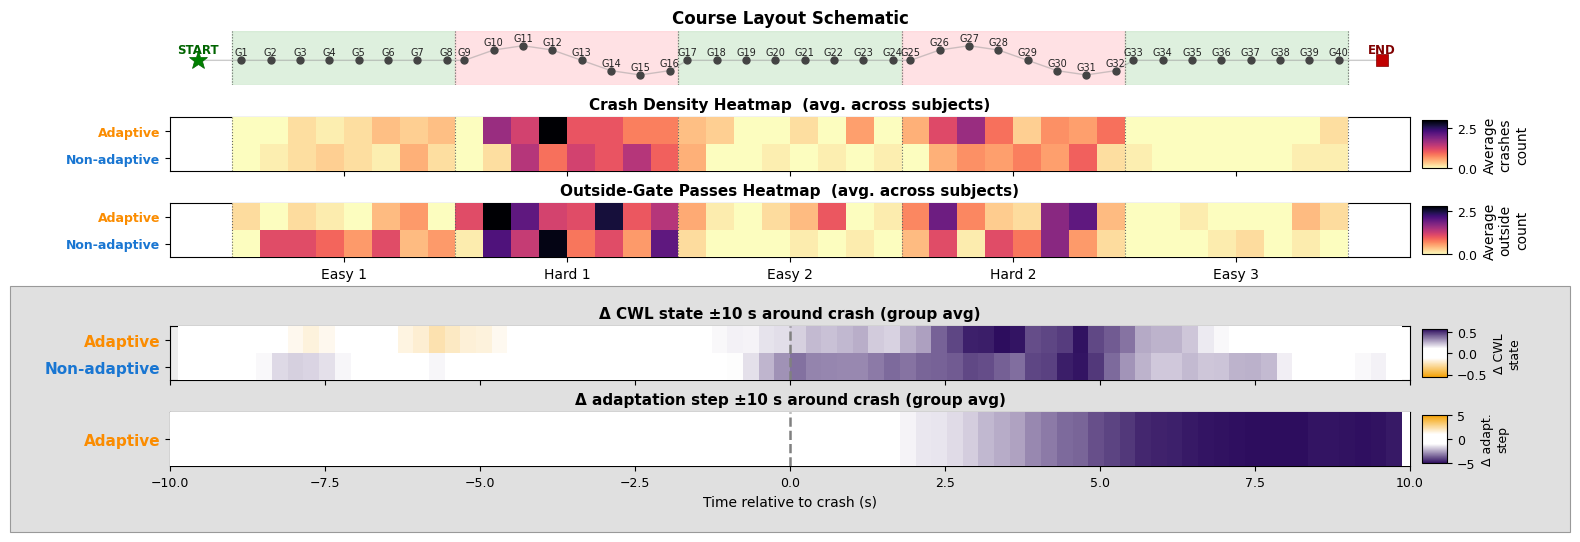

In [330]:
# 5- Crash analysis: heatmaps + crash window
import importlib
import workload_inference.plot_results._experiment as _exp
importlib.reload(_exp)
from workload_inference.plot_results._experiment import (
    _get_sorted_gate_ids,
    _plot_crash_heatmap,
    _plot_crash_window_heatmap,
    _build_mock_course_ax,
    _make_diverging_cmap,
    WINDOW_CMAPS,
)
from workload_inference.plot_results._common import _segment_metadata

# ── Colormap tuning ───────────────────────────────────────────────────────────
# WHITE_WIDTH: fraction of the colormap range that stays neutral (white).
# 0.00 = linear transition (no plateau)
# 0.20 = ±10% of the data range is white — emphasises sharp transitions
# 0.40 = ±20% is white — only strong deviations show color
WHITE_WIDTH = 0.20

# ══════════════════════════════════════════════════════════════════════════════
# COLOR THEME — swap the active block to switch between themes
# ══════════════════════════════════════════════════════════════════════════════

# ── MAGMA THEME (active) ──────────────────────────────────────────────────────
# Sequential heatmaps: magma_r  (light yellow = 0, dark purple = max)
# Diverging window:   dark magma purple ↔ warm magma orange, white plateau
CRASH_CMAP        = "magma_r"
OUTSIDE_CMAP      = "magma_r"
WINDOW_CWL_CMAP   = _make_diverging_cmap("magma_div_cwl", "#f4a000", "#2d0d5e", white_width=WHITE_WIDTH)
WINDOW_STEP_CMAP  = _make_diverging_cmap("magma_div_step", "#2d0d5e", "#f4a000", white_width=WHITE_WIDTH)

# ── ORIGINAL THEME (commented out — uncomment to revert) ─────────────────────
# CRASH_CMAP        = None   # → default "YlOrRd"
# OUTSIDE_CMAP      = None   # → default "YlGnBu"
# WINDOW_CWL_CMAP   = _make_diverging_cmap("vik_like_nb", "#001959", "#7B0700", white_width=WHITE_WIDTH)
# WINDOW_STEP_CMAP  = _make_diverging_cmap("vik_like_nb", "#001959", "#7B0700", white_width=WHITE_WIDTH)

# ══════════════════════════════════════════════════════════════════════════════

DELTA    = True   # plot variation vs. start-of-window (reveals inference lag)
AVERAGED = True   # False = one row per subject; True = one row per group
# ─────────────────────────────────────────────────────────────────────────────

ref_gates = next(
    (tr["gates"] for trials in by_subject.values() for tr in trials if tr["gates"] is not None),
    None,
)

if ref_gates is None:
    print("No gate data found.")
else:
    sorted_gate_ids = _get_sorted_gate_ids(ref_gates)
    _, _, seg_names_r, seg_diffs_r = _segment_metadata(ref_gates)
    n_segs_r = len(seg_names_r)

    n_subj_cr = len(by_subject)
    n_adaptive = sum(1 for g in groups.values() if g == "adaptive")
    spacer_h      = 0.1
    if AVERAGED:
        window_h      = 1.0
        window_h_step = window_h
        heatmap_h     = window_h
    else:
        heatmap_h     = max(1.2, n_subj_cr * 0.28)
        window_h      = max(2.5, n_subj_cr * 0.38)
        window_h_step = max(2.5, n_adaptive * 0.38)

    fig_cr = plt.figure(figsize=(16, min(10, 1.5 + 2 * heatmap_h + window_h + window_h_step)))
    gs_cr = fig_cr.add_gridspec(
        6, 1,
        height_ratios=[1, heatmap_h, heatmap_h, spacer_h, window_h, window_h_step],
        hspace=0.7,
    )
    ax_mock    = fig_cr.add_subplot(gs_cr[0])
    ax_heat    = fig_cr.add_subplot(gs_cr[1], sharex=ax_mock)
    ax_outside = fig_cr.add_subplot(gs_cr[2], sharex=ax_mock)
    ax_cwl     = fig_cr.add_subplot(gs_cr[4])
    ax_stp     = fig_cr.add_subplot(gs_cr[5])

    _build_mock_course_ax(ax_mock, seg_names_r, seg_diffs_r)
    _plot_crash_heatmap(
        ax_heat, by_subject, groups, sorted_gate_ids,
        n_segs_r, seg_diffs_r, seg_names_r,
        metric="crashes", averaged=AVERAGED, cmap_name=CRASH_CMAP,
        show_xlabels=False, show_legend=not AVERAGED,
    )
    _plot_crash_heatmap(
        ax_outside, by_subject, groups, sorted_gate_ids,
        n_segs_r, seg_diffs_r, seg_names_r,
        metric="outside", averaged=AVERAGED, cmap_name=OUTSIDE_CMAP,
        show_xlabels=True,
    )
    ax_mock.tick_params(bottom=False, labelbottom=False)

    _plot_crash_window_heatmap(
        ax_cwl, ax_stp, by_subject, groups,
        delta=DELTA, averaged=AVERAGED,
        cwl_cmap_name=WINDOW_CWL_CMAP,
        step_cmap_name=WINDOW_STEP_CMAP,
    )
    # Gray background panel behind the crash-window rows
    # (these axes use time units, not gate units — visual separator)
    from matplotlib.patches import Rectangle as _Rect
    fig_cr.canvas.draw()  # finalise gridspec positions
    _bb_cwl = ax_cwl.get_position()
    _bb_stp = ax_stp.get_position()
    _pad = 0.1
    fig_cr.add_artist(_Rect(
        (_bb_stp.x0 - _pad, _bb_stp.y0 - _pad - 0.02),
        (_bb_cwl.x1 - _bb_stp.x0) + 2 * _pad,
        (_bb_cwl.y1 - _bb_stp.y0) + 2 * _pad,
        facecolor="#e0e0e0", edgecolor="#999999", linewidth=0.8,
        transform=fig_cr.transFigure, zorder=0, clip_on=False,
    ))
    plt.subplots_adjust(top=0.9)
    fig_cr.savefig("data/results/racing_gates_crash_analysis_heatmaps.svg")
plt.show()


In [252]:
# 5a — Crash / Outside-gate summary table: per-gate mean ± std, by group
# ─────────────────────────────────────────────────────────────────────────────
# For each gate, each subject contributes the SUM across all their trials.
# We then report mean ± std of those per-subject sums, split by group.
# MWU tests compare hard vs. easy segment totals within each group.
# ─────────────────────────────────────────────────────────────────────────────
import importlib
import workload_inference.plot_results._experiment as _exp
importlib.reload(_exp)
from workload_inference.plot_results._experiment import (
    _crash_density_per_gate,
    _outside_density_per_gate,
    _get_sorted_gate_ids,
    _iqr_filter,
)
from workload_inference.plot_results._common import _segment_metadata
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

# ── Re-use the same gate reference and segment info as the heatmap cell ───────
ref_gates = next(
    (tr["gates"] for trials in by_subject.values() for tr in trials if tr["gates"] is not None),
    None,
)
sorted_gate_ids = _get_sorted_gate_ids(ref_gates)
_, _, seg_names_r, seg_diffs_r = _segment_metadata(ref_gates)
n_per_seg = 8

# Build a segment label for each gate position
gate_segment_labels = []
for i, gid in enumerate(sorted_gate_ids):
    seg_idx = i // n_per_seg
    seg_label = seg_names_r[seg_idx] if seg_idx < len(seg_names_r) else f"Seg{seg_idx}"
    gate_segment_labels.append(f"Gate {gid:02d}  [{seg_label}]")

# ── Compute per-subject, per-gate totals (sum over all trials) ────────────────
def _per_subject_gate_totals(density_fn):
    """Returns dict: group → 2-D array (n_subjects × n_gates), totals per subject."""
    result = {"adaptive": [], "non_adaptive": []}
    for g in ["adaptive", "non_adaptive"]:
        sids_g = sorted(
            sid for sid, grp in groups.items()
            if grp == g and sid in by_subject and not sid.startswith("_")
        )
        for sid in sids_g:
            v = np.zeros(len(sorted_gate_ids), dtype=float)
            for tr in by_subject[sid]:
                if tr.get("gates") is not None:
                    v += density_fn(tr, sorted_gate_ids)
            result[g].append(v)
        result[g] = np.array(result[g]) if result[g] else np.empty((0, len(sorted_gate_ids)))
    return result


def _build_summary_df(density_fn):
    data = _per_subject_gate_totals(density_fn)
    rows = []
    for i, label in enumerate(gate_segment_labels):
        row = {"Gate": label}
        for g, g_label in [("adaptive", "Adaptive"), ("non_adaptive", "Non-Adaptive")]:
            vals = data[g][:, i] if data[g].shape[0] > 0 else np.array([])
            row[f"{g_label} mean"] = round(vals.mean(), 3) if len(vals) else float("nan")
            row[f"{g_label} std"]  = round(vals.std(),  3) if len(vals) else float("nan")
            row[f"{g_label} n"]    = len(vals)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Gate")


def _build_summary_df(density_fn):
    data = _per_subject_gate_totals(density_fn)
    rows = []
    for i, label in enumerate(gate_segment_labels):
        row = {"Gate": label}
        for g, g_label in [("adaptive", "Adaptive"), ("non_adaptive", "Non-Adaptive")]:
            vals = data[g][:, i] if data[g].shape[0] > 0 else np.array([])
            row[f"{g_label} mean"] = round(vals.mean(), 3) if len(vals) else float("nan")
            row[f"{g_label} std"]  = round(vals.std(),  3) if len(vals) else float("nan")
            row[f"{g_label} n"]    = len(vals)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Gate")


crash_summary   = _build_summary_df(_crash_density_per_gate)
outside_summary = _build_summary_df(_outside_density_per_gate)

# ── Per-segment aggregation (sum all 8 gates within each segment) ─────────────
def _segment_aggregate(density_fn):
    data = _per_subject_gate_totals(density_fn)
    rows = []
    for seg_idx, seg_label in enumerate(seg_names_r):
        gate_slice = slice(seg_idx * n_per_seg, (seg_idx + 1) * n_per_seg)
        row = {"Segment": seg_label, "Hard": bool(seg_diffs_r[seg_idx])}
        for g, g_label in [("adaptive", "Adaptive"), ("non_adaptive", "Non-Adaptive")]:
            vals = data[g][:, gate_slice].sum(axis=1) if data[g].shape[0] > 0 else np.array([])
            row[f"{g_label} mean"] = round(vals.mean(), 3) if len(vals) else float("nan")
            row[f"{g_label} std"]  = round(vals.std(),  3) if len(vals) else float("nan")
        rows.append(row)
    return pd.DataFrame(rows).set_index("Segment")


crash_seg   = _segment_aggregate(_crash_density_per_gate)
outside_seg = _segment_aggregate(_outside_density_per_gate)

# ── MWU: hard vs. easy segments within each group ─────────────────────────────
# Each observation = one subject's total for one segment (summed across trials).
# Hard segments: Hard 1, Hard 2  (seg_diffs_r = True)
# Easy segments: Easy 1, Easy 2, Easy 3  (seg_diffs_r = False)

def _stars(p):
    for t, s in [(0.001, "***"), (0.01, "**"), (0.05, "*")]:
        if p < t:
            return s
    return "ns"


def _mwu_hard_easy(density_fn, metric_label):
    data = _per_subject_gate_totals(density_fn)
    hard_idxs = [i for i, is_hard in enumerate(seg_diffs_r) if is_hard]
    easy_idxs = [i for i, is_hard in enumerate(seg_diffs_r) if not is_hard]

    print(f"  {metric_label}")
    print(f"  Hard segments : {[seg_names_r[i] for i in hard_idxs]}")
    print(f"  Easy segments : {[seg_names_r[i] for i in easy_idxs]}")
    print()

    for g, g_label in [("adaptive", "Adaptive"), ("non_adaptive", "Non-Adaptive")]:
        mat = data[g]  # shape (n_subjects, n_gates)
        if mat.shape[0] == 0:
            print(f"  {g_label}: no data")
            continue

        # Per-subject segment totals: sum the 8 gates in each segment
        seg_totals = np.stack(
            [mat[:, seg_idx * n_per_seg:(seg_idx + 1) * n_per_seg].sum(axis=1)
             for seg_idx in range(len(seg_names_r))],
            axis=1,
        )  # shape (n_subjects, n_segments)

        # Pool all hard / easy observations (one value per subject per segment)
        hard_vals = seg_totals[:, hard_idxs].flatten()
        easy_vals = seg_totals[:, easy_idxs].flatten()

        hard_filt = _iqr_filter(hard_vals)
        easy_filt = _iqr_filter(easy_vals)

        if len(hard_filt) < 2 or len(easy_filt) < 2:
            print(f"  {g_label}: insufficient data after filtering")
            continue

        U, p = mannwhitneyu(hard_filt, easy_filt, alternative="two-sided")
        r_rb = 1 - 2 * U / (len(hard_filt) * len(easy_filt))

        print(f"  {g_label}  (n={mat.shape[0]} subjects)")
        print(f"    Hard: mean={hard_vals.mean():.3f}  std={hard_vals.std():.3f}  "
              f"(n={len(hard_vals)} obs, {len(hard_filt)} after IQR filter)")
        print(f"    Easy: mean={easy_vals.mean():.3f}  std={easy_vals.std():.3f}  "
              f"(n={len(easy_vals)} obs, {len(easy_filt)} after IQR filter)")
        print(f"    MWU  U={U:.0f},  p={p:.4f} {_stars(p)},  r={r_rb:+.3f}")
        print()


# ── Display ───────────────────────────────────────────────────────────────────
print("═" * 70)
print("  CRASHES — per-segment summary  (total across all trials per subject)")
print("═" * 70)
display(crash_seg)

print()
print("═" * 70)
print("  OUTSIDE GATE — per-segment summary  (total across all trials per subject)")
print("═" * 70)
display(outside_seg)

print()
print("═" * 70)
print("  MWU: Hard vs. Easy segments — Crashes")
print("═" * 70)
_mwu_hard_easy(_crash_density_per_gate, "Crashes (dead drones approaching gate)")

print("═" * 70)
print("  MWU: Hard vs. Easy segments — Outside Gate Passes")
print("═" * 70)
_mwu_hard_easy(_outside_density_per_gate, "Outside gate passes (alive drones)")

print()
print("═" * 70)
print("  CRASHES — per-gate detail")
print("═" * 70)
display(crash_summary)

print()
print("═" * 70)
print("  OUTSIDE GATE — per-gate detail")
print("═" * 70)
display(outside_summary)


══════════════════════════════════════════════════════════════════════
  CRASHES — per-segment summary  (total across all trials per subject)
══════════════════════════════════════════════════════════════════════


,Hard,Adaptive mean,Adaptive std,Non-Adaptive mean,Non-Adaptive std
Segment,,,,,
Easy 1,False,1.6,2.107,1.6,3.040
Hard 1,True,9.8,6.306,7.5,4.455
Easy 2,False,1.5,1.500,0.8,1.661
Hard 2,True,6.8,2.821,4.4,2.939
Easy 3,False,0.2,0.400,0.3,0.458



══════════════════════════════════════════════════════════════════════
  OUTSIDE GATE — per-segment summary  (total across all trials per subject)
══════════════════════════════════════════════════════════════════════


,Hard,Adaptive mean,Adaptive std,Non-Adaptive mean,Non-Adaptive std
Segment,,,,,
Easy 1,False,1.5,1.628,5.8,10.515
Hard 1,True,13.1,11.945,10.7,9.737
Easy 2,False,2.3,3.437,0.4,0.663
Hard 2,True,7.9,5.394,6.0,4.050
Easy 3,False,0.7,1.005,0.4,0.917



══════════════════════════════════════════════════════════════════════
  MWU: Hard vs. Easy segments — Crashes
══════════════════════════════════════════════════════════════════════
  Crashes (dead drones approaching gate)
  Hard segments : ['Hard 1', 'Hard 2']
  Easy segments : ['Easy 1', 'Easy 2', 'Easy 3']

  Adaptive  (n=10 subjects)
    Hard: mean=8.300  std=5.110  (n=20 obs, 17 after IQR filter)
    Easy: mean=1.100  std=1.640  (n=30 obs, 29 after IQR filter)
    MWU  U=478,  p=0.0000 ***,  r=-0.937

  Non-Adaptive  (n=10 subjects)
    Hard: mean=5.950  std=4.080  (n=20 obs, 20 after IQR filter)
    Easy: mean=0.900  std=2.087  (n=30 obs, 25 after IQR filter)
    MWU  U=472,  p=0.0000 ***,  r=-0.888

══════════════════════════════════════════════════════════════════════
  MWU: Hard vs. Easy segments — Outside Gate Passes
══════════════════════════════════════════════════════════════════════
  Outside gate passes (alive drones)
  Hard segments : ['Hard 1', 'Hard 2']
  Easy segmen

,Adaptive mean,Adaptive std,Adaptive n,Non-Adaptive mean,Non-Adaptive std,Non-Adaptive n
Gate,,,,,,
Gate 00 [Easy 1],0.0,0.000,10,0.0,0.000,10
Gate 01 [Easy 1],0.0,0.000,10,0.1,0.300,10
Gate 02 [Easy 1],0.2,0.400,10,0.2,0.600,10
Gate 03 [Easy 1],0.1,0.300,10,0.3,0.900,10
Gate 04 [Easy 1],0.2,0.600,10,0.2,0.600,10
Gate 05 [Easy 1],0.4,0.800,10,0.1,0.300,10
Gate 06 [Easy 1],0.3,0.640,10,0.5,0.806,10
Gate 07 [Easy 1],0.4,1.200,10,0.2,0.400,10
Gate 08 [Hard 1],0.0,0.000,10,0.0,0.000,10



══════════════════════════════════════════════════════════════════════
  OUTSIDE GATE — per-gate detail
══════════════════════════════════════════════════════════════════════


,Adaptive mean,Adaptive std,Adaptive n,Non-Adaptive mean,Non-Adaptive std,Non-Adaptive n
Gate,,,,,,
Gate 00 [Easy 1],0.2,0.600,10,0.0,0.000,10
Gate 01 [Easy 1],0.0,0.000,10,1.1,2.982,10
Gate 02 [Easy 1],0.2,0.600,10,1.1,3.300,10
Gate 03 [Easy 1],0.1,0.300,10,0.9,2.385,10
Gate 04 [Easy 1],0.0,0.000,10,0.6,1.281,10
Gate 05 [Easy 1],0.4,0.663,10,1.1,2.211,10
Gate 06 [Easy 1],0.6,1.200,10,0.4,1.200,10
Gate 07 [Easy 1],0.0,0.000,10,0.6,1.800,10
Gate 08 [Hard 1],1.1,2.071,10,0.1,0.300,10


In [ ]:
# Explore more than 10 seconds around the crashes, to see if there are any patterns in the lead-up or aftermath.



In [219]:
# 5b — Post-crash Adaptation Rate
# For each crash event (drone death), measure the total step delta from the
# crash moment to the end of the post-crash window:
#   delta = step(t_crash + POST_S) - step(t_crash)
# A delta <= -STEP_THRESHOLD means the system reacted and applied tighter
# flight limits (negative = step went down = more restriction).
#
# Outputs: adaptation rate per group + 95% Wilson CI + per-subject breakdown.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from scipy.stats import binomtest
from importlib import reload
import workload_inference.plot_results._experiment as _exp
reload(_exp)
from workload_inference.plot_results._experiment import _find_drone_death_timestamps

# ── Parameters ────────────────────────────────────────────────────────────────
POST_S          = 10.0  # post-crash window length (seconds)
STEP_THRESHOLD  = 5     # minimum total step decrease to count as "adapted"
#                         MAX_JUMP=6 per cycle → threshold of 6 = at least one
#                         full controller reaction applied by end of window

# ── Collect one record per crash event ────────────────────────────────────────
records = []

for sid, trials in by_subject.items():
    if sid.startswith("_"):
        continue
    group = groups.get(sid, "unknown")
    if group == "unknown":
        continue

    for tr in trials:
        drones   = tr.get("drones")
        commands = tr.get("commands")
        if drones is None or commands is None:
            continue
        if "cwl_current_step" not in commands.columns:
            continue

        for t_death in _find_drone_death_timestamps(drones):
            t_post_ms = t_death + POST_S * 1000

            seg_pre  = commands[commands["timestamp"] <= t_death]["cwl_current_step"].dropna()
            seg_post = commands[
                (commands["timestamp"] > t_death) & (commands["timestamp"] <= t_post_ms)
            ]["cwl_current_step"].dropna()

            if seg_pre.empty or seg_post.empty:
                continue

            step_at_crash = float(seg_pre.iloc[-1])
            step_at_end   = float(seg_post.iloc[-1])
            delta         = step_at_end - step_at_crash  # negative = stepped down
            adapted       = delta <= -STEP_THRESHOLD

            records.append({
                "subject_id":    sid,
                "group":         group,
                "step_at_crash": step_at_crash,
                "step_at_end":   step_at_end,
                "delta_step":    delta,
                "adapted":       adapted,
            })

rec_df = pd.DataFrame(records)

# ── Adaptation rate per group ─────────────────────────────────────────────────
print(f"{'='*58}")
print(f"  Post-crash Adaptation Rate  (window: 0 – {POST_S:.0f} s)")
print(f"  Criterion : total step decrease ≥ {STEP_THRESHOLD}  (delta ≤ -{STEP_THRESHOLD})")
print(f"{'='*58}")

for g, label in [("adaptive", "Adaptive"), ("non_adaptive", "Non-Adaptive (Control)")]:
    sub = rec_df[rec_df["group"] == g]
    n   = len(sub)
    k   = int(sub["adapted"].sum())
    if n == 0:
        print(f"\n  {label}: no data")
        continue
    rate       = k / n
    ci         = binomtest(k, n).proportion_ci(confidence_level=0.95, method="wilson")
    mean_delta = sub["delta_step"].mean()
    std_delta  = sub["delta_step"].std()
    print(f"\n  {label}")
    print(f"    Crash events  : {n}")
    print(f"    Adapted       : {k}")
    print(f"    Rate          : {rate:.1%}  (95% CI: {ci.low:.1%} – {ci.high:.1%})")
    print(f"    Mean Δstep    : {mean_delta:+.2f} ± {std_delta:.2f}  (negative = stepped down)")

# ── Per-subject breakdown (adaptive group only) ───────────────────────────────
print(f"\n{'='*58}")
print(f"  Per-subject breakdown — Adaptive group")
print(f"{'='*58}")
for sid, sub in rec_df[rec_df["group"] == "adaptive"].groupby("subject_id"):
    n          = len(sub)
    k          = int(sub["adapted"].sum())
    mean_delta = sub["delta_step"].mean()
    std_delta  = sub["delta_step"].std() if n > 1 else float("nan")
    std_str    = f"±{std_delta:.1f}" if not np.isnan(std_delta) else "±n/a"
    print(f"  {sid}: {k}/{n}  ({k/n:.0%})  mean Δstep={mean_delta:+.1f} {std_str}")


  Post-crash Adaptation Rate  (window: 0 – 10 s)
  Criterion : total step decrease ≥ 5  (delta ≤ -5)

  Adaptive
    Crash events  : 191
    Adapted       : 73
    Rate          : 38.2%  (95% CI: 31.6% – 45.3%)
    Mean Δstep    : -4.13 ± 7.56  (negative = stepped down)

  Non-Adaptive (Control)
    Crash events  : 145
    Adapted       : 42
    Rate          : 29.0%  (95% CI: 22.2% – 36.8%)
    Mean Δstep    : -2.42 ± 5.70  (negative = stepped down)

  Per-subject breakdown — Adaptive group
  CXOE: 5/9  (56%)  mean Δstep=-4.1 ±6.1
  EBET: 5/9  (56%)  mean Δstep=-6.6 ±13.2
  ENJS: 8/30  (27%)  mean Δstep=-2.9 ±7.3
  ENQK: 8/16  (50%)  mean Δstep=-4.7 ±8.6
  JPNL: 6/19  (32%)  mean Δstep=-4.1 ±8.1
  JUEC: 5/18  (28%)  mean Δstep=-4.4 ±9.5
  JXKI: 11/27  (41%)  mean Δstep=-3.1 ±5.5
  MZSB: 7/17  (41%)  mean Δstep=-5.3 ±6.5
  VHFP: 11/20  (55%)  mean Δstep=-7.5 ±6.9
  VXKX: 7/26  (27%)  mean Δstep=-1.8 ±6.0
